### Imports

In [1]:
import time
from collections import defaultdict
from typing import Any, Callable, Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pmdarima as pm
import scipy.stats as sps
import seaborn as sns
import statsmodels
import statsmodels.api as sm
import sys
import torch
import tsfresh
from catboost import CatBoostRegressor
from IPython.display import HTML, clear_output, display
from prophet import Prophet
from pylab import rcParams
from sktime.split import ExpandingWindowSplitter
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
)
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from statsforecast import models as sf_models
from statsforecast.models import (
    SimpleExponentialSmoothing,
    SimpleExponentialSmoothingOptimized,
)
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt, SimpleExpSmoothing
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from torch import nn
from torch.utils.data import DataLoader, Dataset, random_split
from tqdm import tqdm
from tqdm.auto import tqdm as auto_tqdm
from tsfresh import extract_features, select_features
from tsfresh.feature_extraction import settings
from tsfresh.utilities.dataframe_functions import impute, roll_time_series

# Visualization setup
sns.set(font_scale=1.3, palette="Set2")
rcParams['figure.figsize'] = 15, 7
%matplotlib inline

In [2]:
sys.path.append('/home/danilach/mipt-stats/SberTs')

%load_ext autoreload
%autoreload 2

from utils.models import DummyConditionalModel, VARModel
from utils.vis import plot_error_matrix, plot_model_pred, calc_average_error, visualize_ts
from utils.interface import cross_validate_model, calc_avg_error, build_error_matrix, build_short_error_matrix

In [3]:
df = pd.read_csv("/home/danilach/mipt-stats/SberTs/Data/chemicals_nona.csv", index_col=0)
df.index = pd.to_datetime(df.index)
cols = df.columns
df.head()       

,Карбамид (FOB Южный),"Моноаммонийфосфат, MAP (FOB Балтика)",Апатитовый концетрат (FOB Morocco),Аммиак (FOB Черное море),Аммиачная селитра (FOB Черное море),Хлорид калия (CFR Ю-В Азия),Капролактам импортный контракт (Тайвань и Ю. Корея) CFR Азия,Метанол,"Бензол, CFR Япония","Этилен, CFR Китай"
Date,,,,,,,,,,
2016-01-01,209.875,366.25,120.0,266.666667,199.375,278.750,1153.0,185.40,556.00,987.50
2016-02-01,207.125,332.50,117.5,260.500000,182.125,272.500,1163.0,150.00,546.25,927.50
2016-03-01,199.875,345.00,117.5,267.500000,180.300,267.500,1290.0,164.75,625.00,1173.75
2016-04-01,203.875,346.25,115.0,271.000000,172.000,267.500,1355.0,179.90,642.00,1192.50
2016-05-01,200.500,341.50,107.5,279.250000,154.750,251.875,1278.0,201.25,631.25,1160.00


In [4]:
horizon_list = [12, 24, 36, 48]

## Naive Model

In [5]:
matrix_params = {
    "model_class": DummyConditionalModel,
    "df": df,
    "horizon": 12,
    "stride": 1,
    "start_window": 60,
    "model_params": {},
}

In [6]:
naive_model_matrices = {}

for horizon in tqdm(horizon_list):
    matrix_params["horizon"] = horizon
    naive_model_matrices[horizon] = build_error_matrix(**matrix_params)

100%|██████████| 4/4 [00:01<00:00,  3.72it/s]


### Посмотрим на получвшиеся матрицы ошибок

  0%|          | 0/4 [00:00<?, ?it/s]

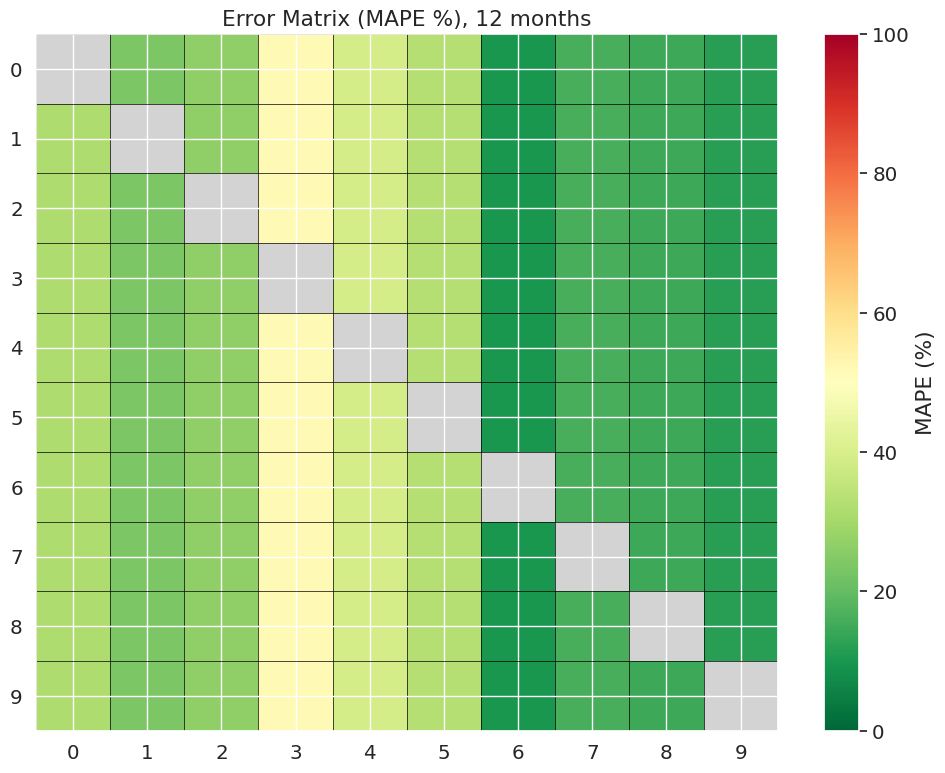

 25%|██▌       | 1/4 [00:00<00:01,  2.61it/s]

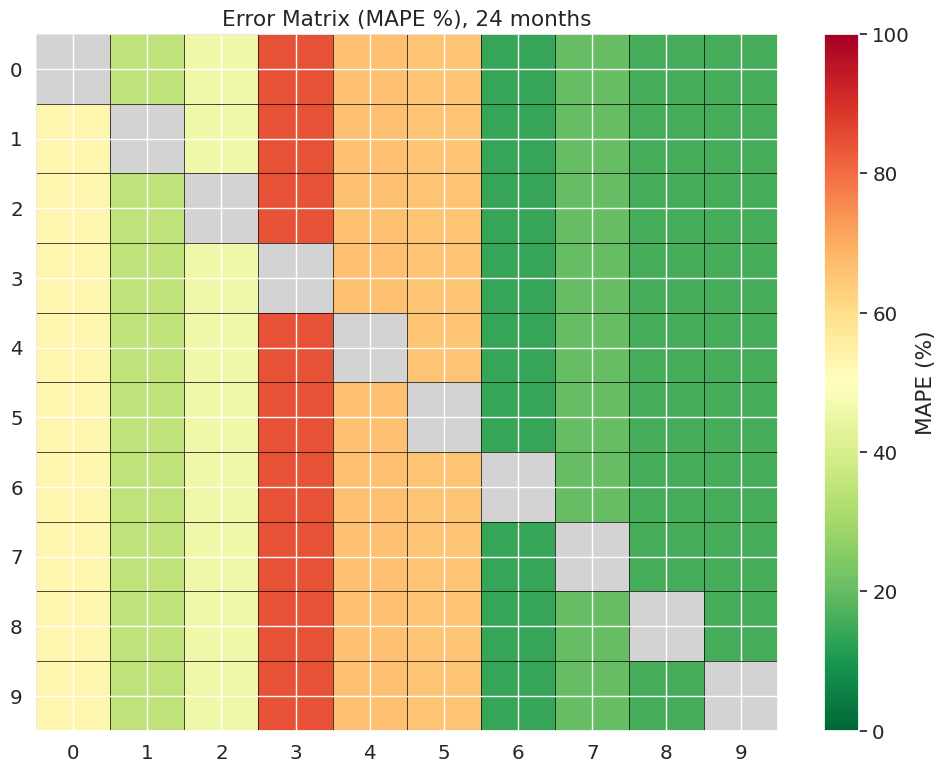

 50%|█████     | 2/4 [00:00<00:00,  2.55it/s]

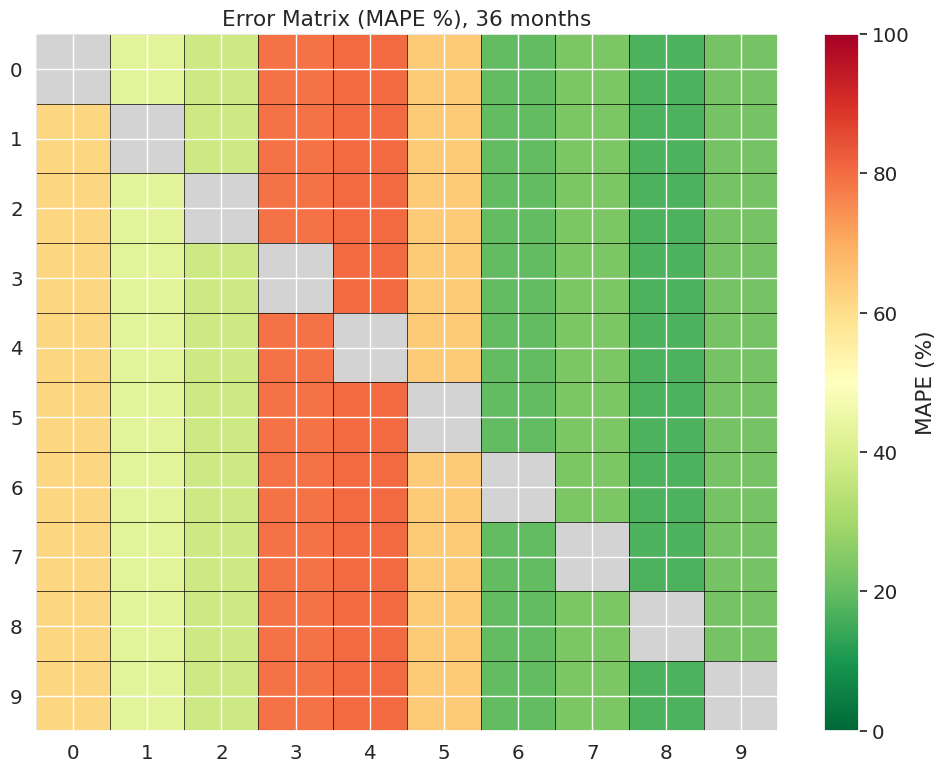

 75%|███████▌  | 3/4 [00:01<00:00,  2.15it/s]

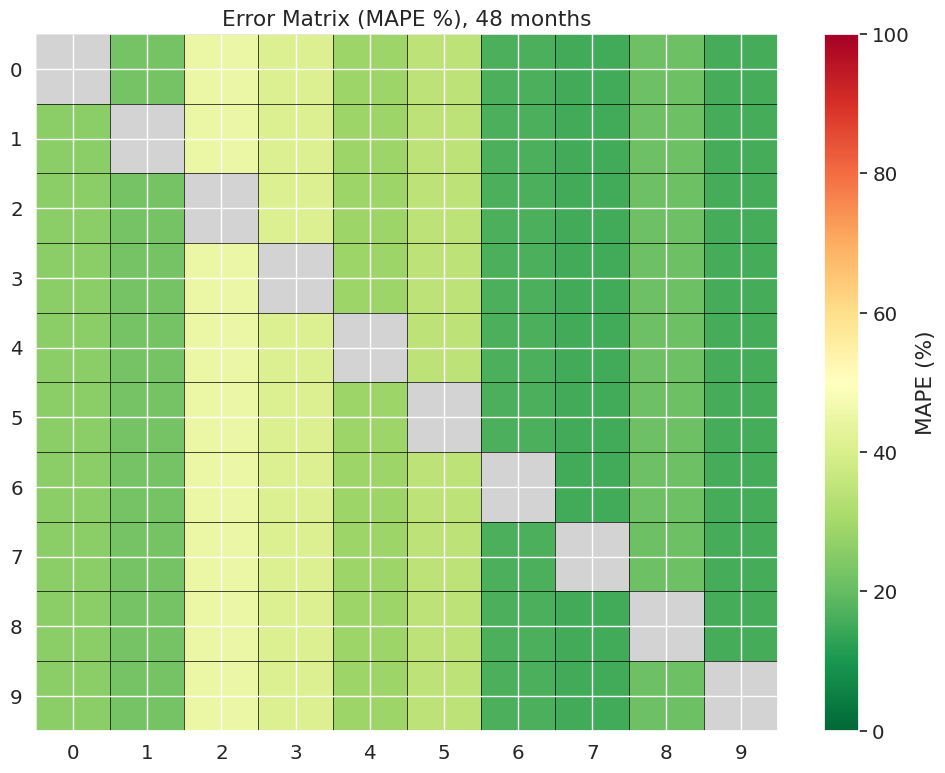

100%|██████████| 4/4 [00:01<00:00,  2.40it/s]


In [7]:
for horizon in tqdm(horizon_list):
    plot_error_matrix(naive_model_matrices[horizon], title=f"Error Matrix (MAPE %), {horizon} months")

### Посмотрим на усреднённый по всем показателям MAPE

In [8]:
for horizon in horizon_list:
    print(f"{horizon} months:    ", end="")
    calc_average_error(naive_model_matrices[horizon])

12 months:    25.87%
24 months:    41.55%
36 months:    44.83%
48 months:    26.73%


Посмотрим также на динамику изменения такого усреднения по мере роста горизонта

In [9]:
avg_mape_list = []

for horizon in tqdm(range(2, 48, 2)):
    matrix_params["horizon"] = horizon
    avg_mape_list.append(np.mean(build_error_matrix(**matrix_params)))

100%|██████████| 23/23 [00:06<00:00,  3.56it/s]


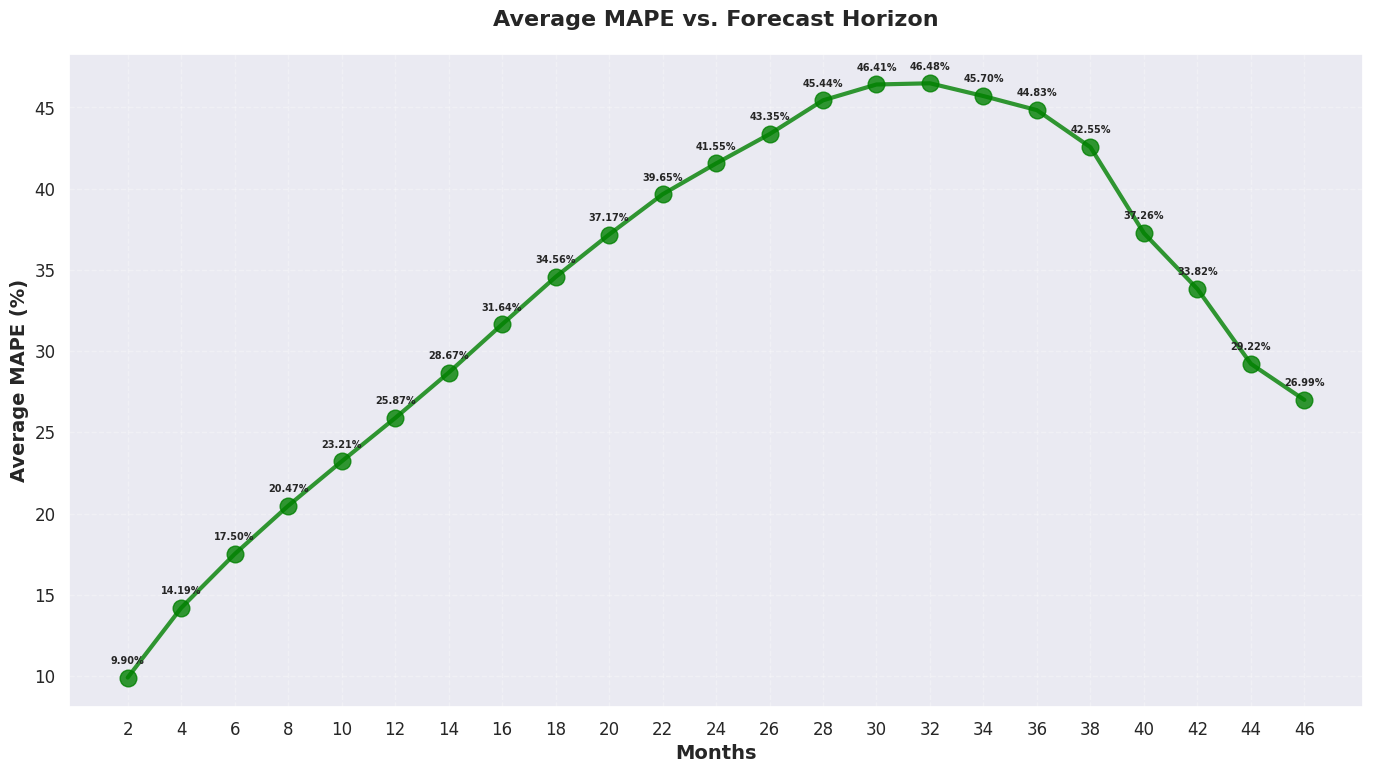

In [10]:
plt.figure(figsize=(14, 8))
plt.plot(
    np.arange(2, 48, 2),
    avg_mape_list,
    marker="o",
    markersize=12,
    color="g",
    linewidth=3,
    linestyle="-",
    alpha=0.8,
)
plt.title("Average MAPE vs. Forecast Horizon", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Months", fontsize=14, fontweight="bold")
plt.ylabel("Average MAPE (%)", fontsize=14, fontweight="bold")

plt.grid(True, alpha=0.3, linestyle="--")
plt.xticks(np.arange(2, 48, 2), fontsize=12)
plt.yticks(fontsize=12)

for i, (x, y) in enumerate(zip(np.arange(2, 48, 2), avg_mape_list)):
    plt.annotate(
        f"{y:.2f}%",
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=7,
        fontweight="bold",
    )


plt.tight_layout()
plt.show()

Посмотрим на траектории средних для каждого показателя

In [11]:
mape_matrix = []

for horizon in tqdm(range(2, 48, 4)):
    matrix_params["horizon"] = horizon
    error_matrix = build_error_matrix(**matrix_params)
    # Calculate mean for each column (axis=0)
    mape_matrix.append(np.mean(error_matrix, axis=0))

mape_matrix = np.array(mape_matrix)


100%|██████████| 12/12 [00:03<00:00,  3.54it/s]


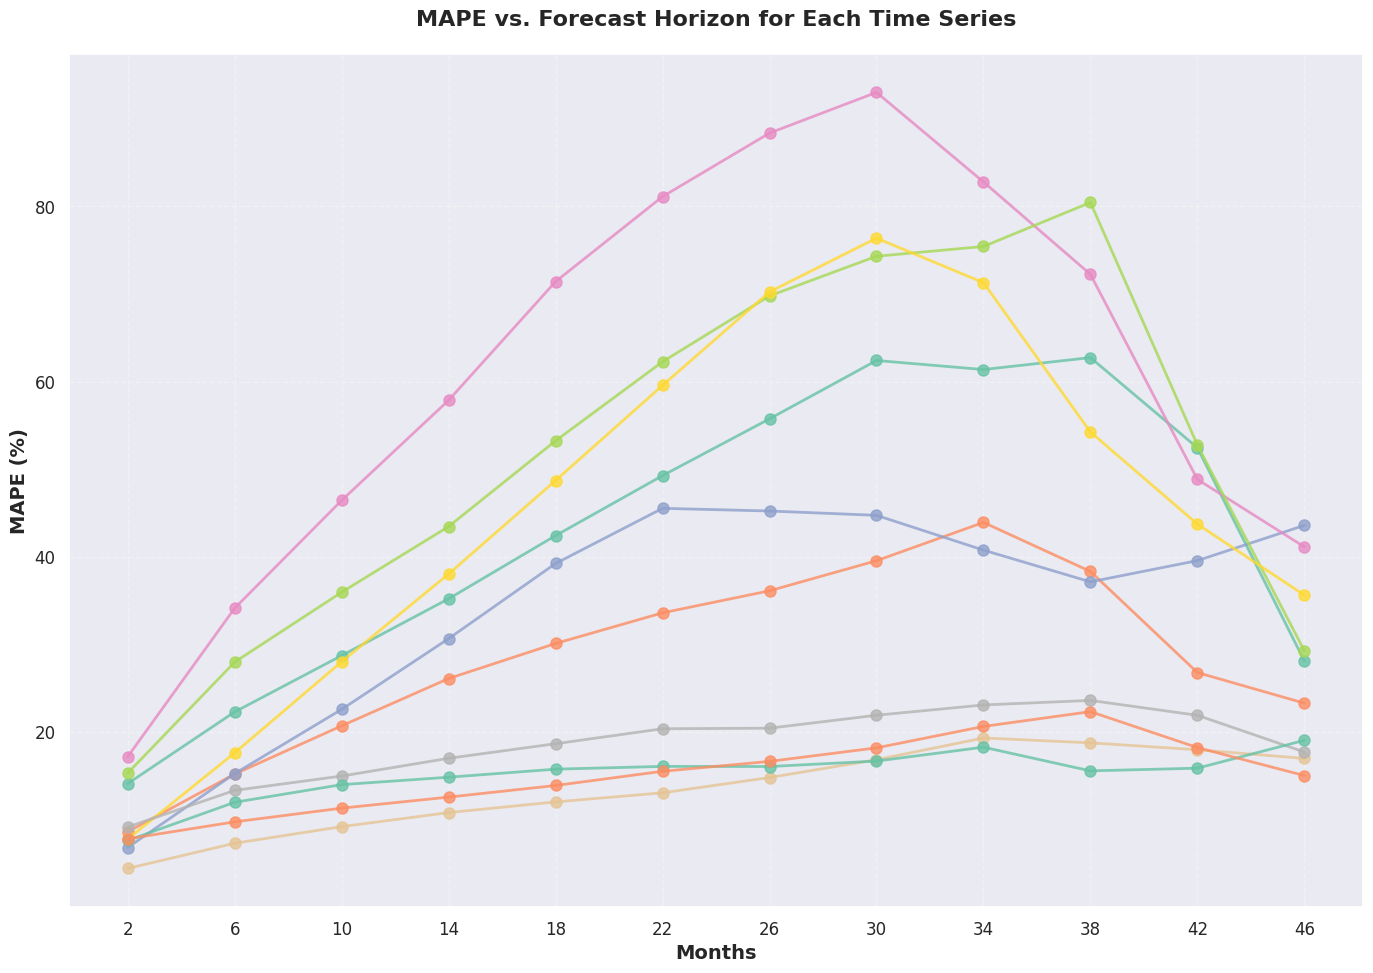

In [12]:
plt.figure(figsize=(14, 10))

for col_idx in range(mape_matrix.shape[1]):
    plt.plot(
        np.arange(2, 48, 4),
        mape_matrix[:, col_idx],
        marker="o",
        markersize=8,
        linewidth=2,
        linestyle="-",
        alpha=0.8,
        label=f"Series {col_idx + 1}",
    )

plt.title(
    "MAPE vs. Forecast Horizon for Each Time Series",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Months", fontsize=14, fontweight="bold")
plt.ylabel("MAPE (%)", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3, linestyle="--")
plt.xticks(np.arange(2, 48, 4), fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

## Prophet

In [57]:
%load_ext autoreload
%autoreload 2

from utils.models import ProphetModel

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
matrix_params = {
    "model_class": ProphetModel,
    "df": df,
    "horizon": 12,
    "stride": 4,
    "start_window": 60,
    "model_params": {},
}

In [59]:
prophet_model_matrices = {}

for horizon in tqdm(horizon_list):
    matrix_params["horizon"] = horizon
    prophet_model_matrices[horizon] = build_short_error_matrix(**matrix_params)

  0%|          | 0/4 [00:00<?, ?it/s]09:39:16 - cmdstanpy - INFO - Chain [1] start processing
09:39:16 - cmdstanpy - INFO - Chain [1] done processing
09:39:16 - cmdstanpy - INFO - Chain [1] start processing
09:39:17 - cmdstanpy - INFO - Chain [1] done processing
09:39:17 - cmdstanpy - INFO - Chain [1] start processing
09:39:17 - cmdstanpy - INFO - Chain [1] done processing
09:39:17 - cmdstanpy - INFO - Chain [1] start processing
09:39:17 - cmdstanpy - INFO - Chain [1] done processing
09:39:17 - cmdstanpy - INFO - Chain [1] start processing
09:39:18 - cmdstanpy - INFO - Chain [1] done processing
09:39:18 - cmdstanpy - INFO - Chain [1] start processing
09:39:18 - cmdstanpy - INFO - Chain [1] done processing
09:39:18 - cmdstanpy - INFO - Chain [1] start processing
09:39:18 - cmdstanpy - INFO - Chain [1] done processing
09:39:18 - cmdstanpy - INFO - Chain [1] start processing
09:39:19 - cmdstanpy - INFO - Chain [1] done processing
09:39:19 - cmdstanpy - INFO - Chain [1] start processing
09

### Посмотрим на получвшиеся матрицы ошибок

  0%|          | 0/4 [00:00<?, ?it/s]

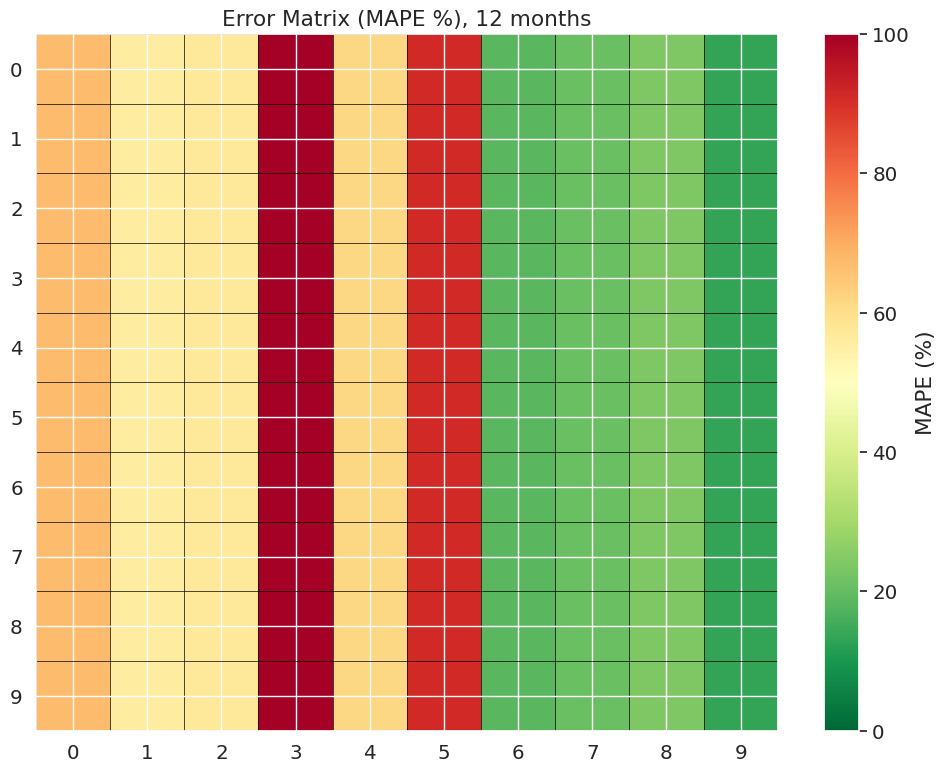

 25%|██▌       | 1/4 [00:00<00:00,  3.11it/s]

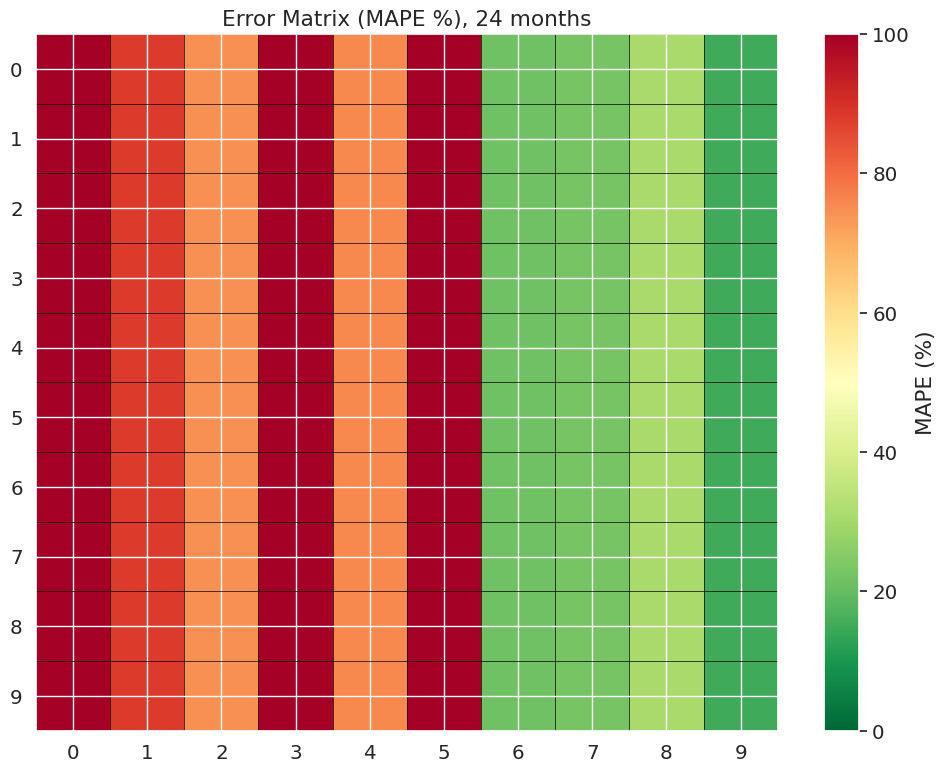

 50%|█████     | 2/4 [00:00<00:00,  3.18it/s]

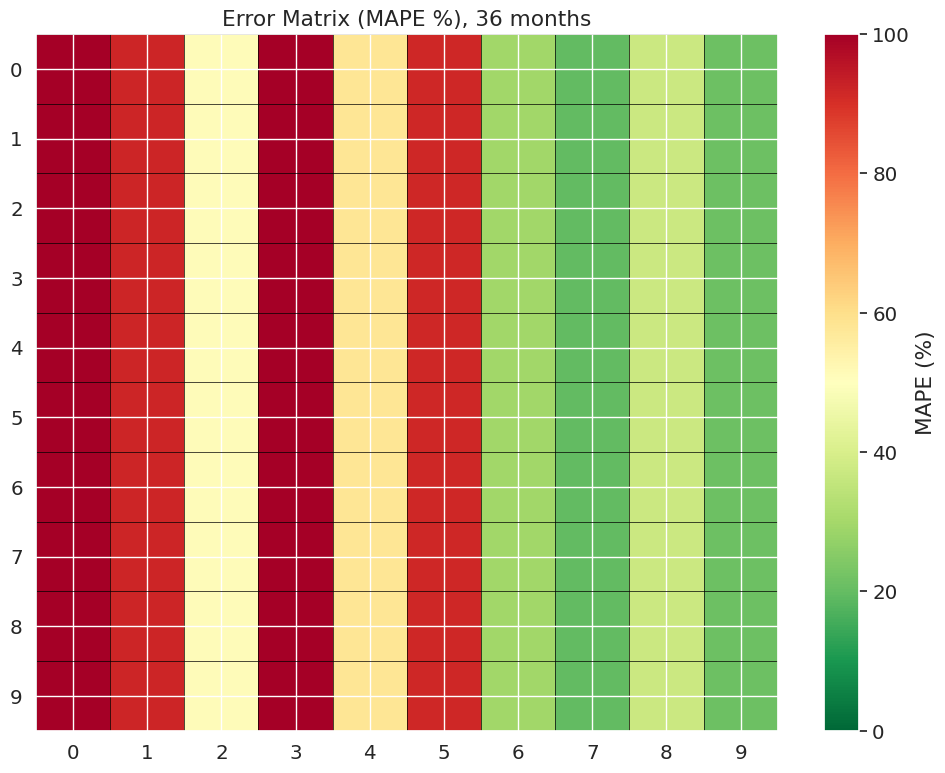

 75%|███████▌  | 3/4 [00:00<00:00,  3.19it/s]

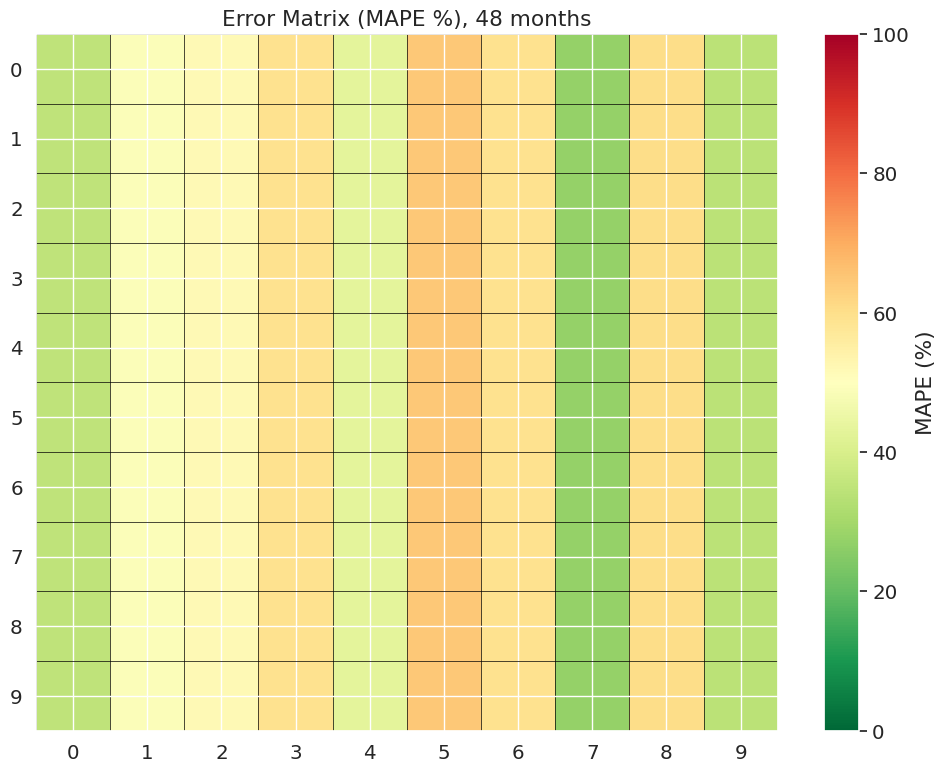

100%|██████████| 4/4 [00:01<00:00,  3.13it/s]


In [60]:
for horizon in tqdm(horizon_list):
    plot_error_matrix(prophet_model_matrices[horizon], title=f"Error Matrix (MAPE %), {horizon} months")

### Посмотрим на усреднённый по всем показателям MAPE

In [61]:
for horizon in horizon_list:
    print(f"{horizon} months:    ", end="")
    calc_average_error(prophet_model_matrices[horizon])


12 months:    51.89%
24 months:    73.40%
36 months:    63.19%
48 months:    48.36%


## Linear Extrapolator

In [19]:
%load_ext autoreload
%autoreload 2

from utils.models import LinearExtrapolator

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
matrix_params = {
    "model_class": LinearExtrapolator,
    "df": df,
    "horizon": 12,
    "stride": 1,
    "start_window": 60,
    "model_params": {},
}

In [21]:
extr_model_matrices = {}

for horizon in tqdm(horizon_list):
    matrix_params["horizon"] = horizon
    extr_model_matrices[horizon] = build_error_matrix(**matrix_params)

100%|██████████| 4/4 [00:00<00:00,  8.83it/s]


### Посмотрим на получвшиеся матрицы ошибок


  0%|          | 0/4 [00:00<?, ?it/s]

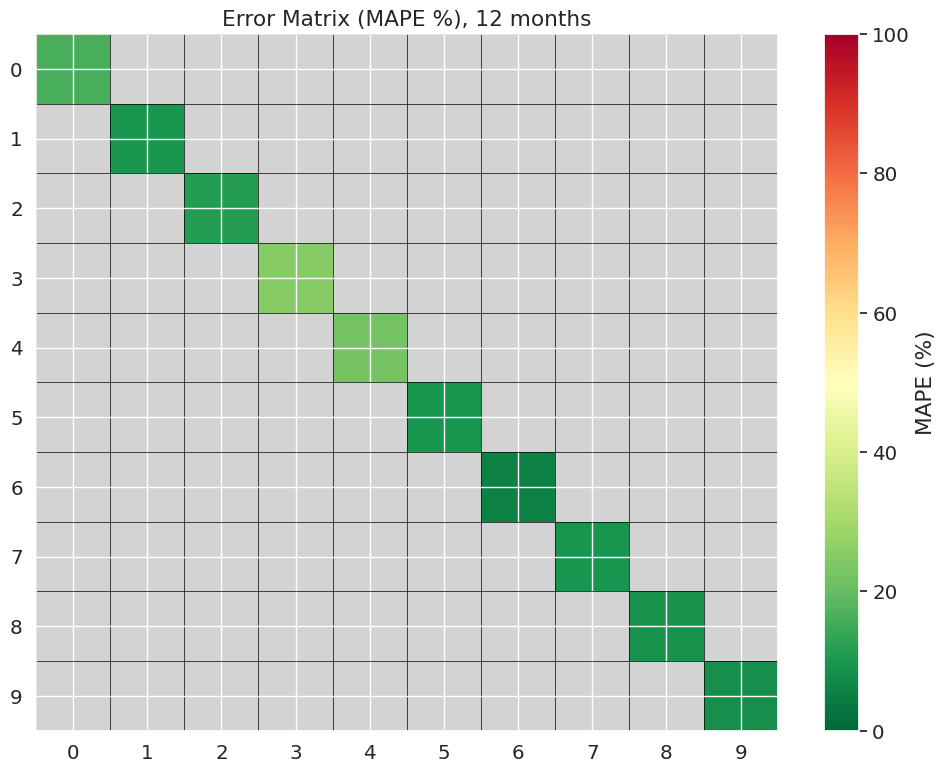

 25%|██▌       | 1/4 [00:00<00:01,  2.80it/s]

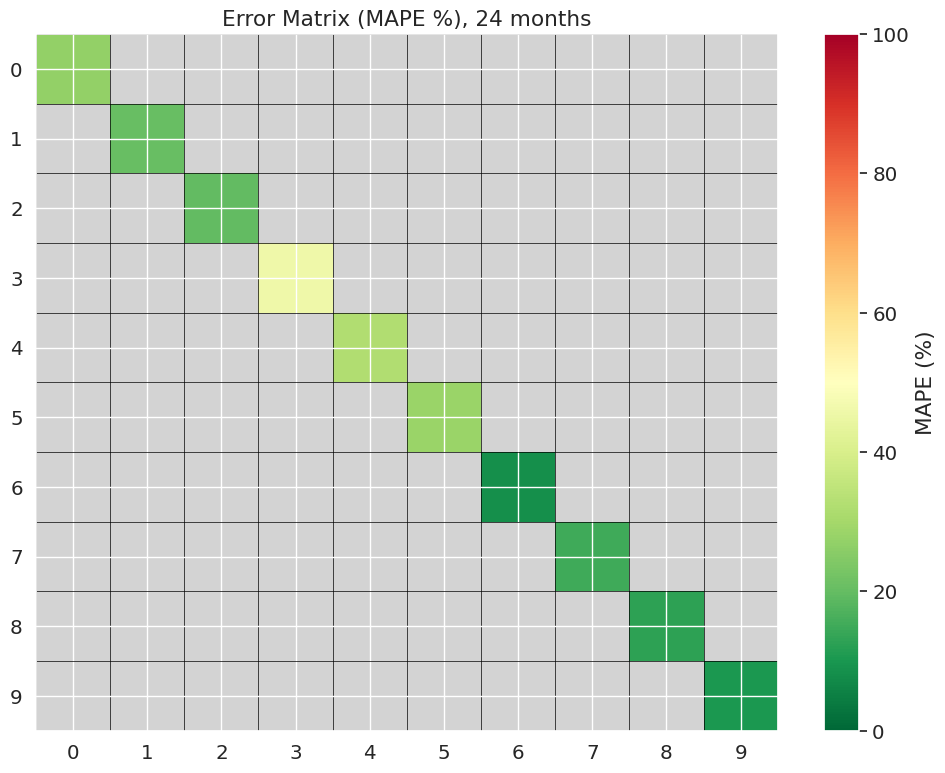

 50%|█████     | 2/4 [00:00<00:00,  2.80it/s]

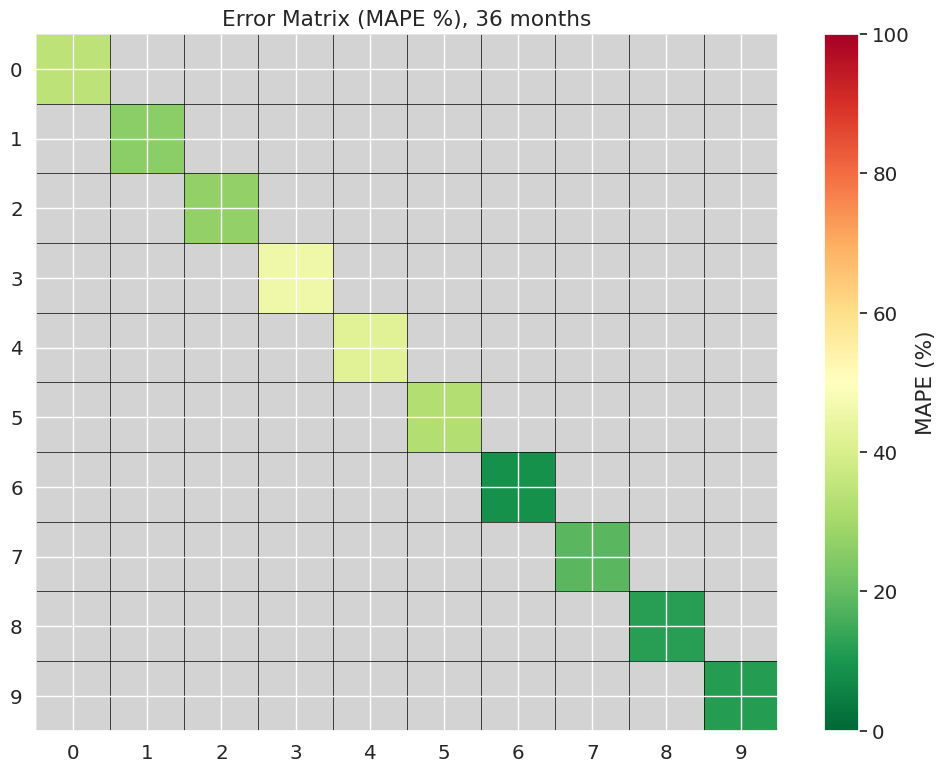

 75%|███████▌  | 3/4 [00:01<00:00,  2.83it/s]

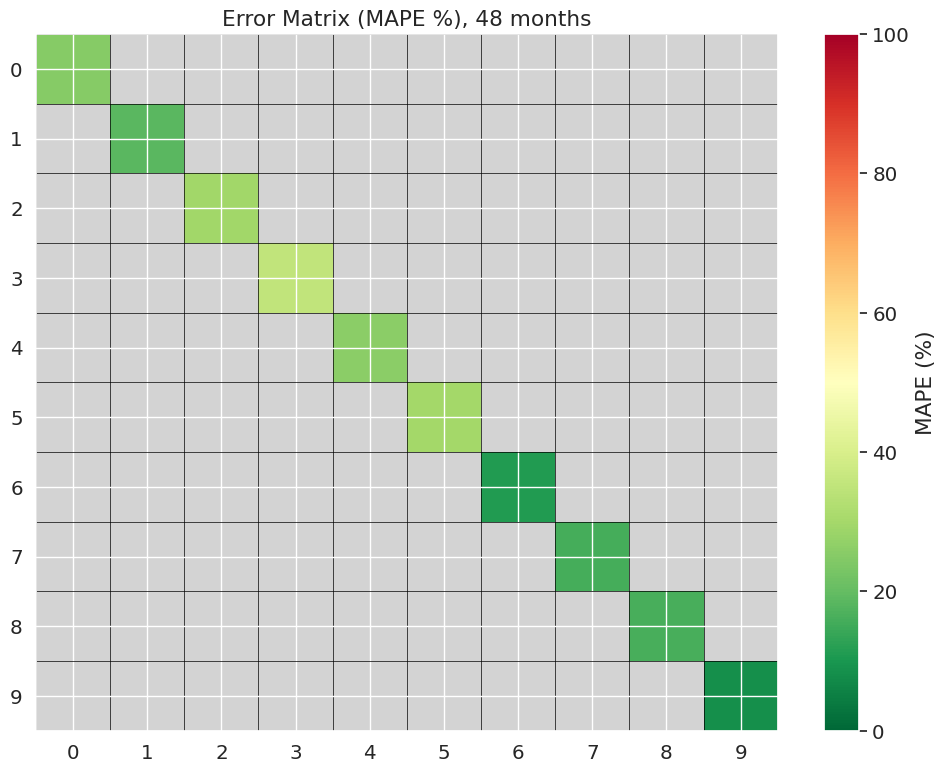

100%|██████████| 4/4 [00:01<00:00,  2.68it/s]


In [22]:
for horizon in tqdm(horizon_list):
    plot_error_matrix(extr_model_matrices[horizon], title=f"Error Matrix (MAPE %), {horizon} months")

### Посмотрим на усреднённый по всем показателям MAPE

In [23]:
for horizon in horizon_list:
    print(f"{horizon} months:    ", end="")
    calc_average_error(extr_model_matrices[horizon])

12 months:    12.69%
24 months:    22.06%
36 months:    25.94%
48 months:    21.59%


In [24]:
avg_mape_list = []
mape_matrix = []

for horizon in tqdm(range(2, 48, 1)):
    matrix_params["horizon"] = horizon
    error_matrix = build_error_matrix(**matrix_params)
    # Calculate mean for each column (axis=0)
    mape_matrix.append(np.mean(error_matrix, axis=0))
    avg_mape_list.append(np.mean(mape_matrix))
mape_matrix = np.array(mape_matrix)

100%|██████████| 23/23 [00:01<00:00, 13.16it/s]


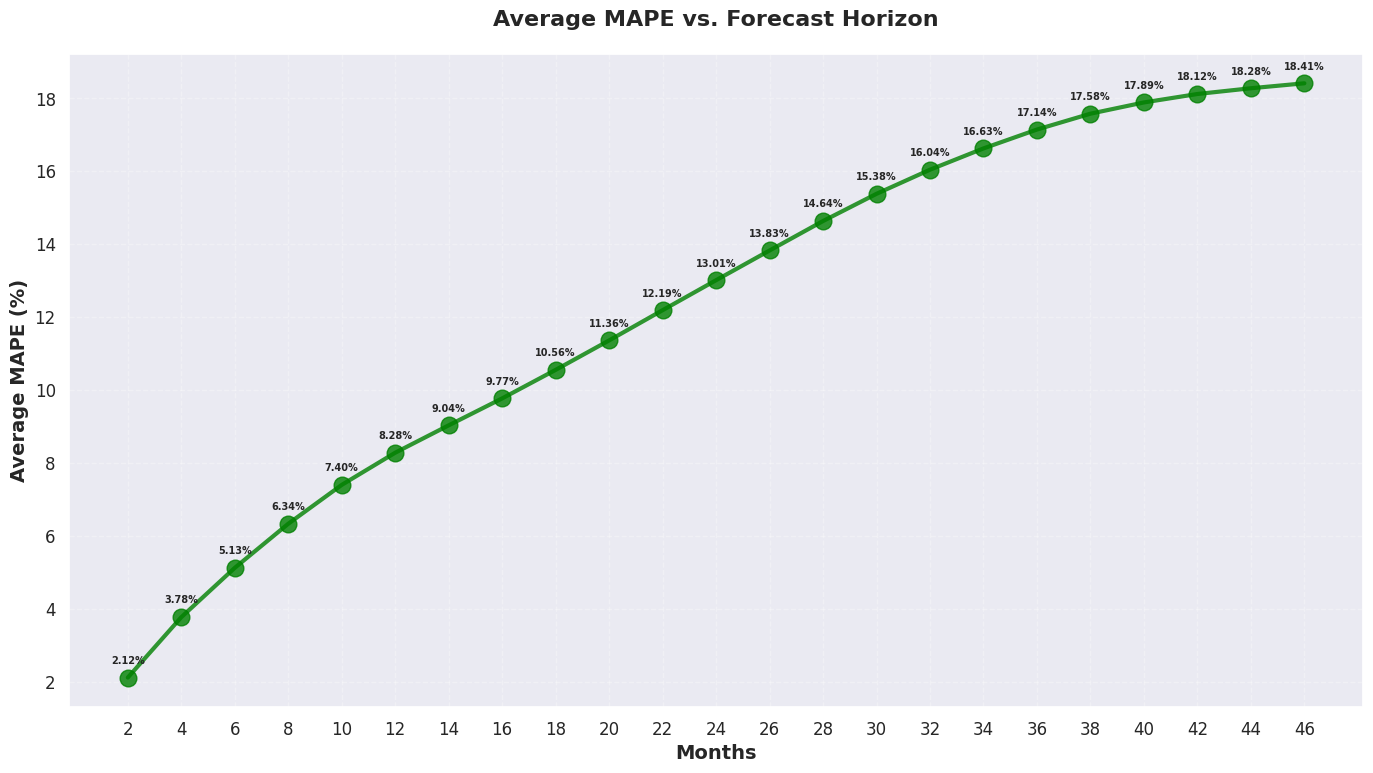

In [ ]:
plt.figure(figsize=(14, 8))
plt.plot(
    np.arange(2, 48, 1),
    avg_mape_list,
    marker="o",
    markersize=12,
    color="g",
    linewidth=3,
    linestyle="-",
    alpha=0.8,
)
plt.title("Average MAPE vs. Forecast Horizon", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Months", fontsize=14, fontweight="bold")
plt.ylabel("Average MAPE (%)", fontsize=14, fontweight="bold")

plt.grid(True, alpha=0.3, linestyle="--")
plt.xticks(np.arange(2, 48, 1), fontsize=12)
plt.yticks(fontsize=12)

for i, (x, y) in enumerate(zip(np.arange(2, 48, 1), avg_mape_list)):
    plt.annotate(
        f"{y:.2f}%",
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=7,
        fontweight="bold",
    )


plt.tight_layout()
plt.show()

In [26]:
mape_matrix = []

for horizon in tqdm(range(2, 48, 4)):
    matrix_params["horizon"] = horizon
    error_matrix = build_error_matrix(**matrix_params)
    # Calculate mean for each column (axis=0)
    mape_matrix.append(np.mean(error_matrix, axis=0))

mape_matrix = np.array(mape_matrix)


100%|██████████| 12/12 [00:00<00:00, 14.70it/s]


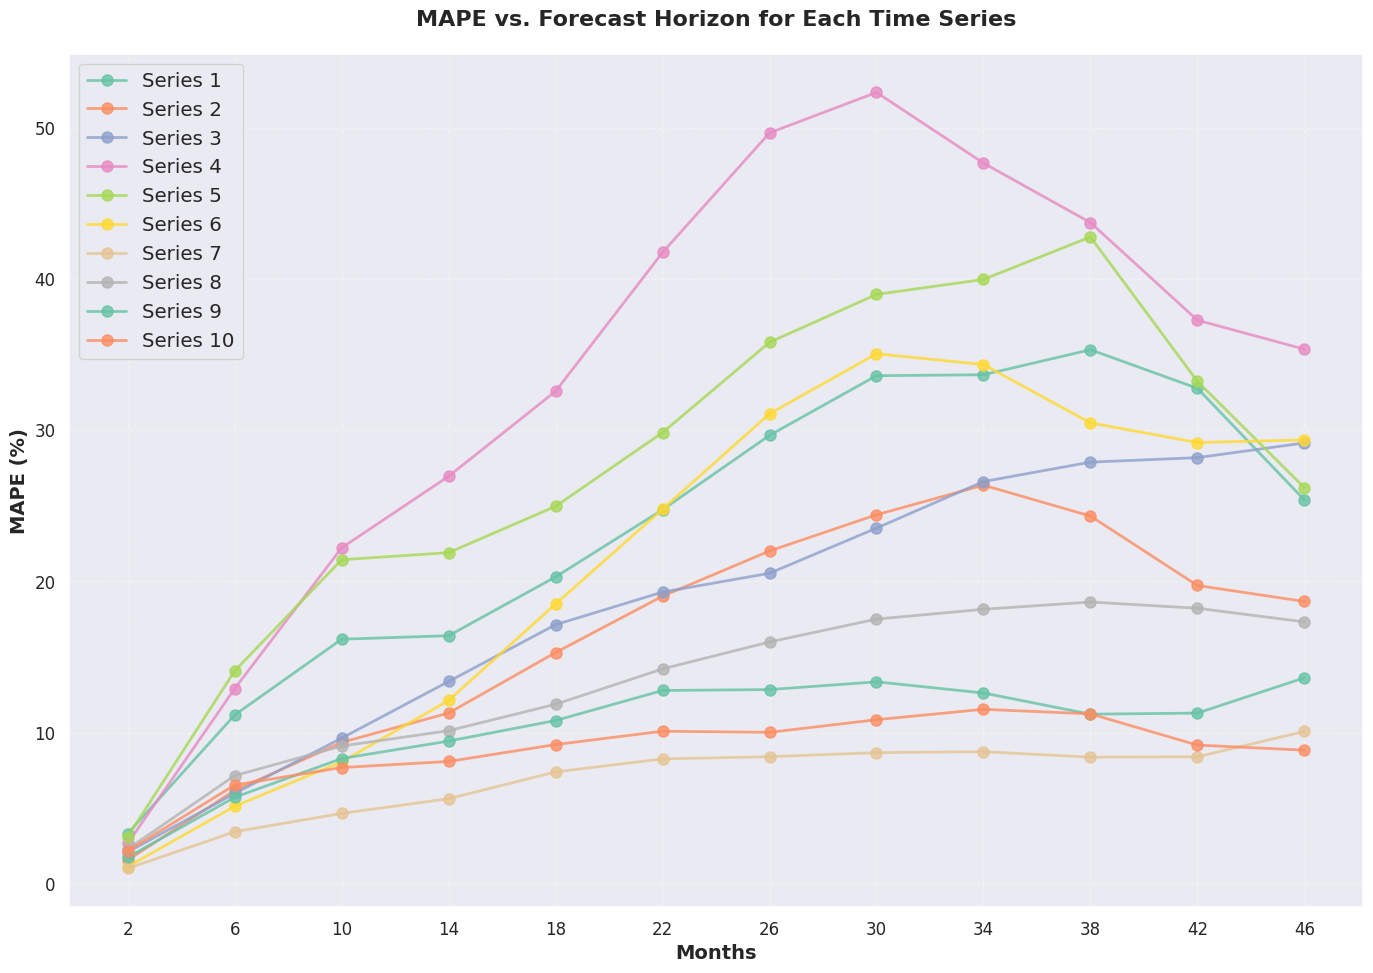

In [39]:
plt.figure(figsize=(14, 10))

for col_idx in range(mape_matrix.shape[1]):
    plt.plot(
        np.arange(2, 48, 4),
        mape_matrix[:, col_idx],
        marker="o",
        markersize=8,
        linewidth=2,
        linestyle="-",
        alpha=0.8,
        label=f"Series {col_idx + 1}",
    )

plt.title(
    "MAPE vs. Forecast Horizon for Each Time Series",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Months", fontsize=14, fontweight="bold")
plt.ylabel("MAPE (%)", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3, linestyle="--")
plt.xticks(np.arange(2, 48, 4), fontsize=12)
plt.yticks(fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

## Mix Model

Посмотрев на результаты экспериментов является очевидным смешать модели. В качестве базовой будет выступать последнее значение, на диагонали линейный экстраполятор, а помидоры и огурцы предсказывает сарима

In [28]:
%load_ext autoreload
%autoreload 2

from utils.models import MixModel, LinearExtrapolator

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
matrix_params = {
    "model_class": MixModel,
    "df": df,
    "horizon": 12,
    "stride": 1,
    "start_window": 60,
    "model_params": {},
}

In [30]:
mix_model_matrices = {}

for horizon in tqdm(horizon_list):
    matrix_params["horizon"] = horizon
    mix_model_matrices[horizon] = build_error_matrix(**matrix_params)

100%|██████████| 4/4 [00:01<00:00,  2.72it/s]


In [31]:
matrix_params = {
    "model_class": LinearExtrapolator,
    "df": df,
    "horizon": 12,
    "stride": 1,
    "start_window": 60,
    "model_params": {},
}
le_model_matrices = {}

for horizon in tqdm(horizon_list):
    matrix_params["horizon"] = horizon
    le_model_matrices[f"{horizon}"] = build_error_matrix(**matrix_params)

100%|██████████| 4/4 [00:00<00:00, 17.51it/s]


### Посмотрим на получвшиеся матрицы ошибок

In [32]:
sota = {}

for horizon in horizon_list:
    sota[f"{horizon}"] = mix_model_matrices[horizon].copy()
    for i in range(len(sota[f"{horizon}"])):
        if i not in [34, 35]:
            sota[f"{horizon}"].iloc[i, i] = le_model_matrices[f"{horizon}"].iloc[i, i]

  0%|          | 0/4 [00:00<?, ?it/s]

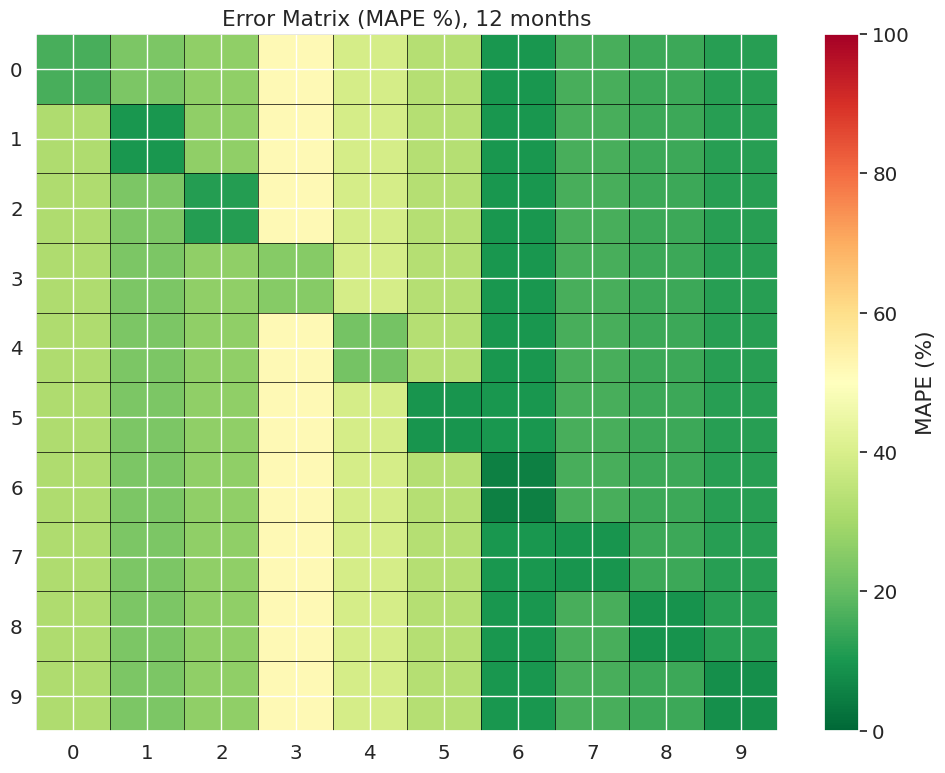

 25%|██▌       | 1/4 [00:00<00:00,  3.18it/s]

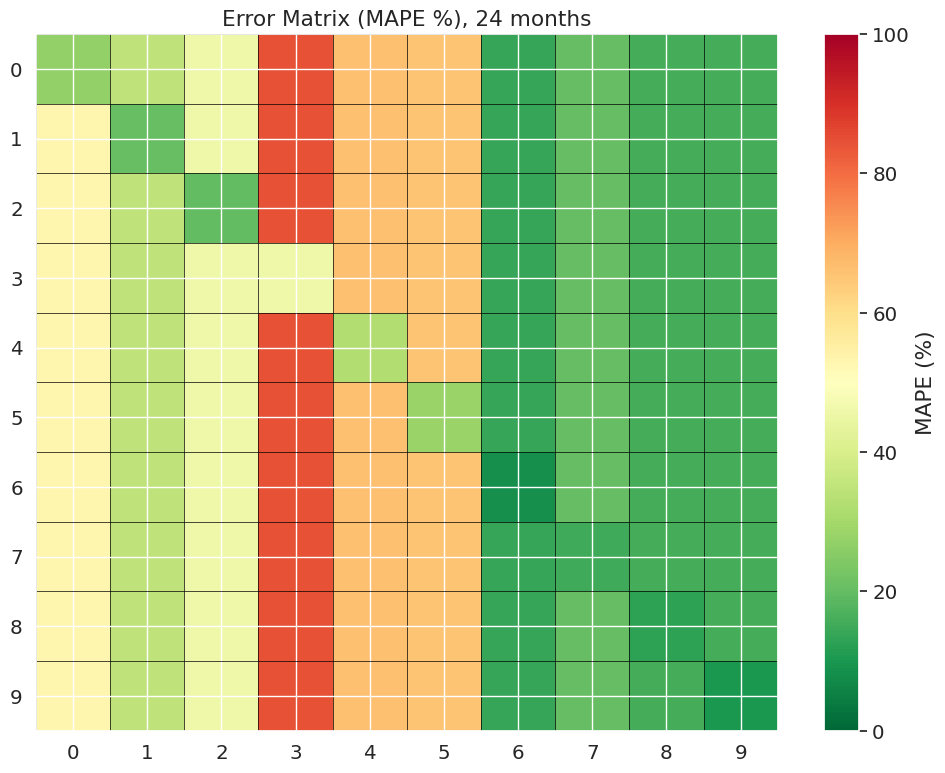

 50%|█████     | 2/4 [00:00<00:00,  3.14it/s]

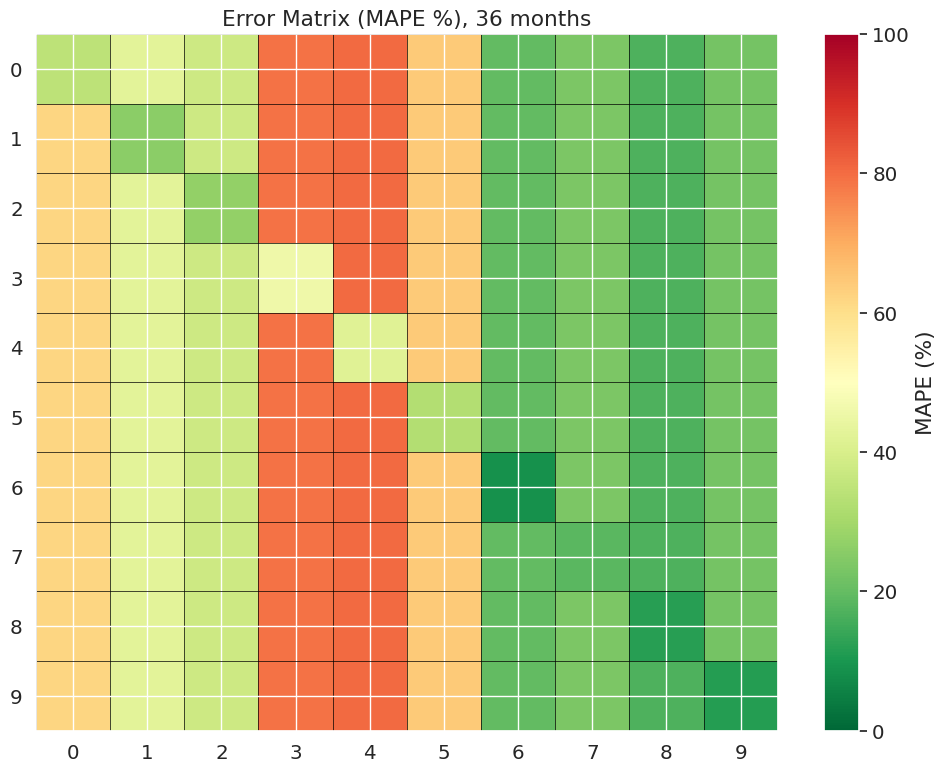

 75%|███████▌  | 3/4 [00:00<00:00,  2.99it/s]

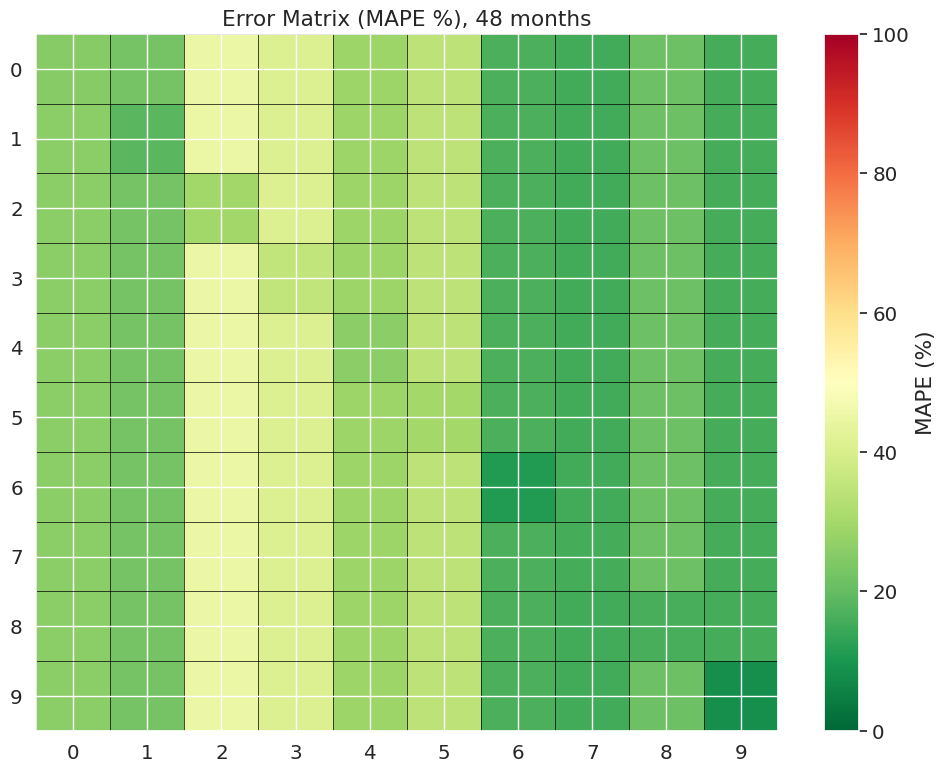

100%|██████████| 4/4 [00:01<00:00,  2.82it/s]


In [33]:
for horizon in tqdm(horizon_list):
    plot_error_matrix(sota[f"{horizon}"], title=f"Error Matrix (MAPE %), {horizon} months")

### Посмотрим на усреднённый по всем показателям MAPE

In [48]:
for horizon in horizon_list:
    print(f"{horizon} months:    ", end="")
    calc_average_error(sota[f"{horizon}"])

12 months:    24.56%
24 months:    39.60%
36 months:    42.94%
48 months:    26.22%


### Посмотрим на разницу

In [35]:
%load_ext autoreload
%autoreload 2

from utils.vis import plot_delta_matrix_anchored

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


  0%|          | 0/4 [00:00<?, ?it/s]

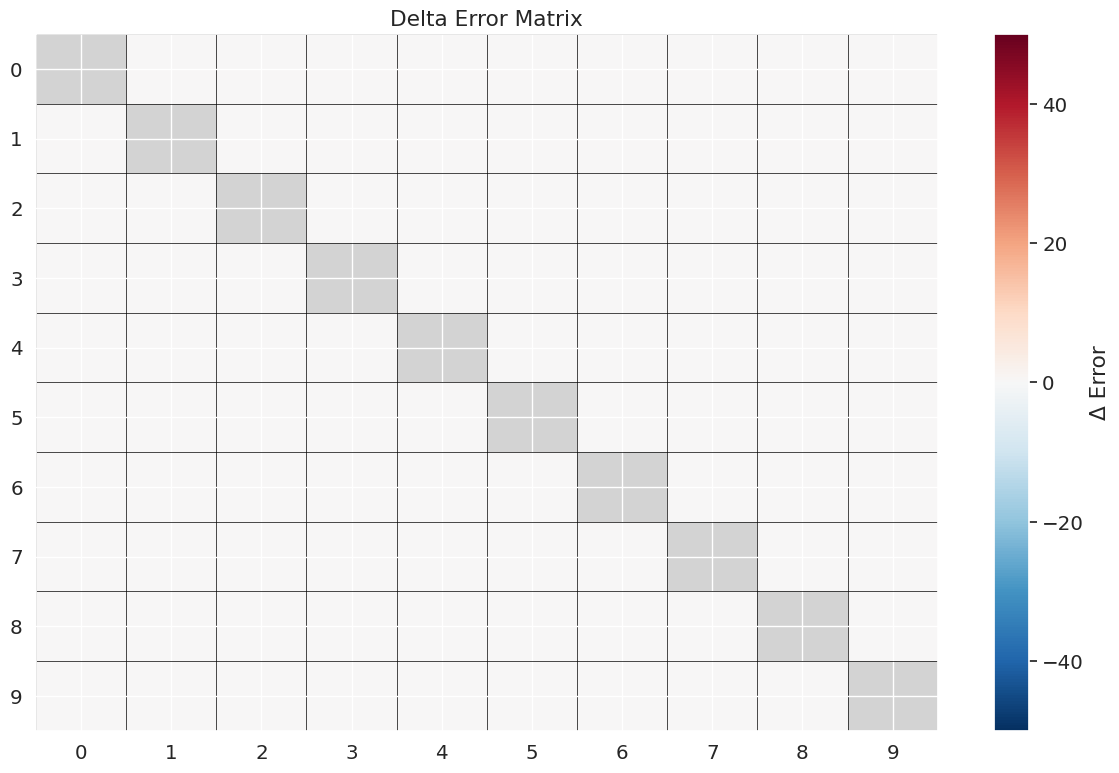

 25%|██▌       | 1/4 [00:00<00:01,  2.75it/s]

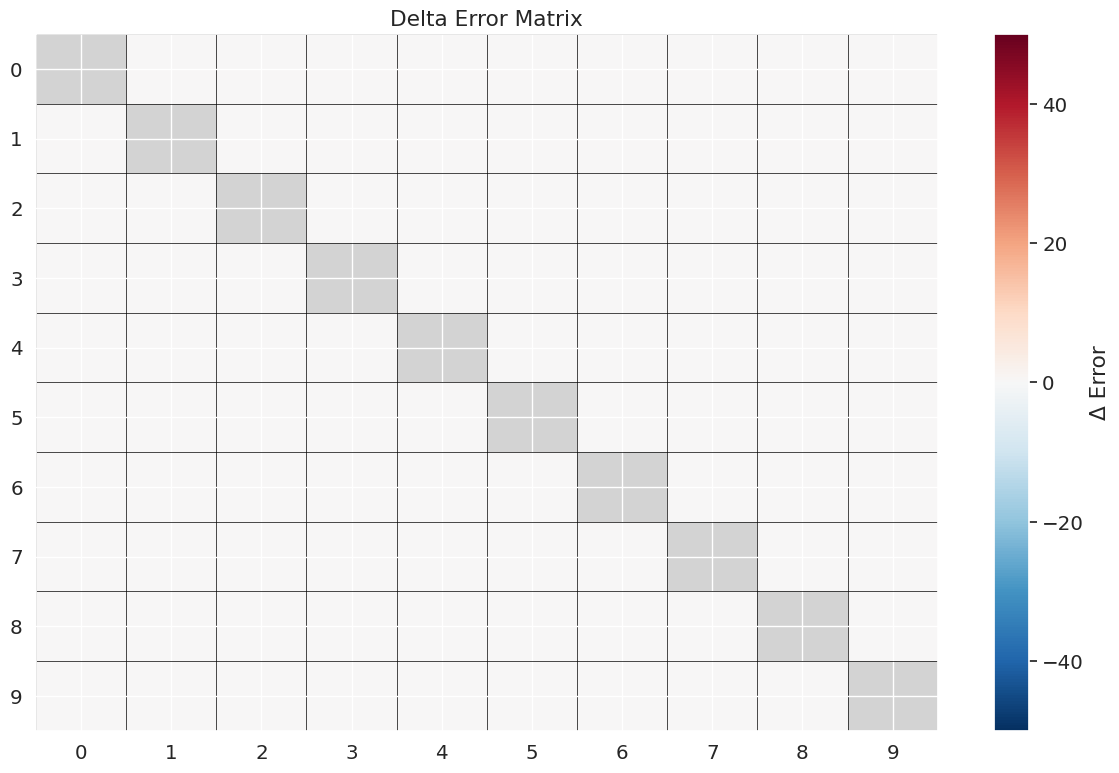

 50%|█████     | 2/4 [00:00<00:00,  2.73it/s]

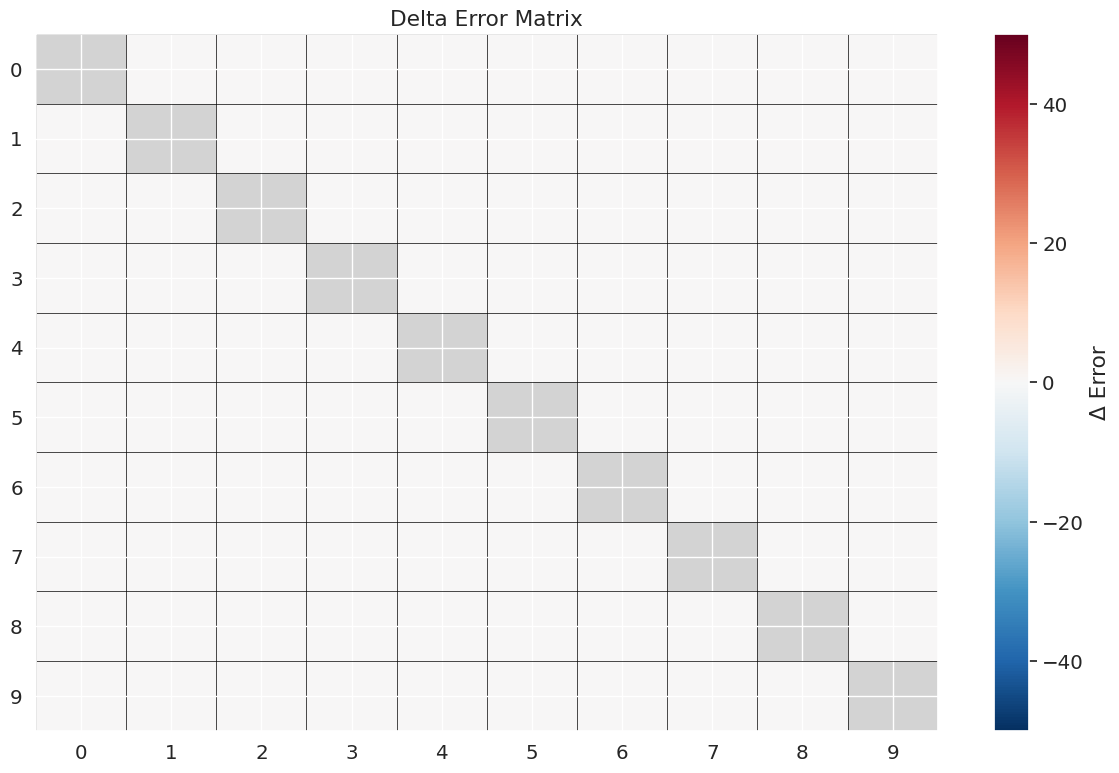

 75%|███████▌  | 3/4 [00:01<00:00,  2.68it/s]

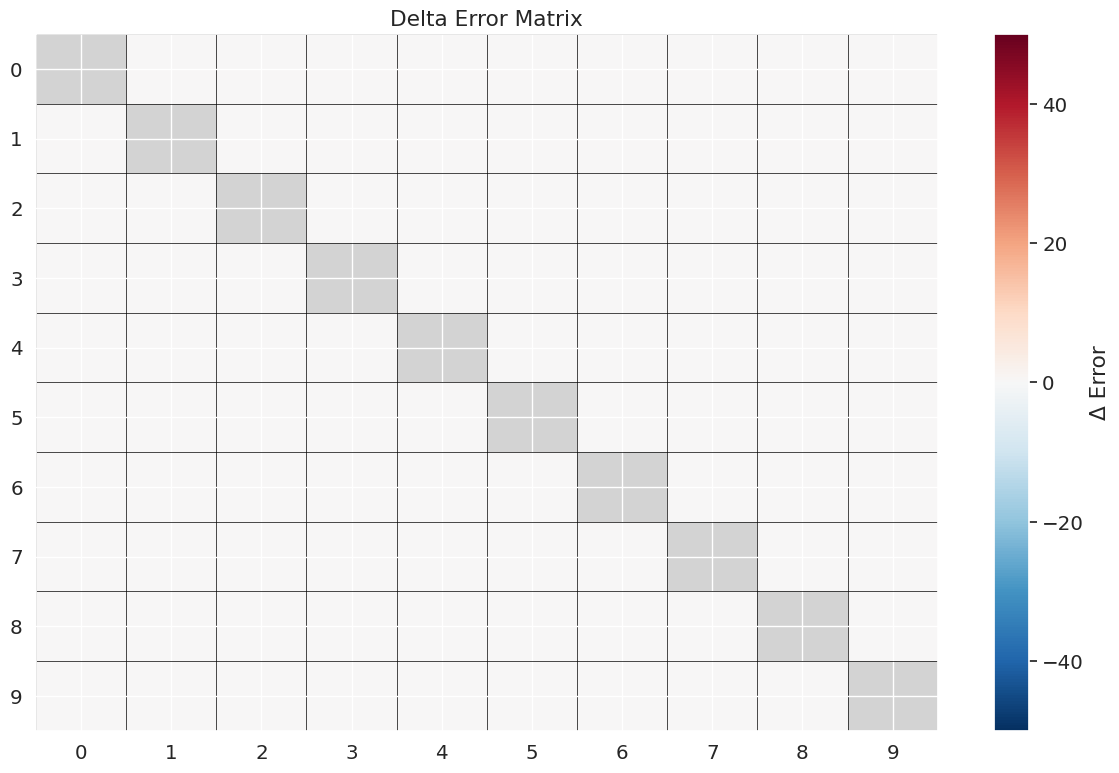

100%|██████████| 4/4 [00:01<00:00,  2.67it/s]


In [36]:
for horizon in tqdm(horizon_list):
    plot_delta_matrix_anchored(sota[f"{horizon}"], naive_model_matrices[horizon])

## Посмотрим на ряды

(<Figure size 1400x3000 with 10 Axes>,
 array([<Axes: title={'center': 'Карбамид (FOB Южный)'}, ylabel='Price'>,
        <Axes: title={'center': 'Моноаммонийфосфат, MAP (FOB Балтика)'}, ylabel='Price'>,
        <Axes: title={'center': 'Апатитовый концетрат (FOB Morocco)'}, ylabel='Price'>,
        <Axes: title={'center': 'Аммиак (FOB Черное море)'}, ylabel='Price'>,
        <Axes: title={'center': 'Аммиачная селитра (FOB Черное море)'}, ylabel='Price'>,
        <Axes: title={'center': 'Хлорид калия (CFR Ю-В Азия)'}, ylabel='Price'>,
        <Axes: title={'center': 'Капролактам импортный контракт (Тайвань и Ю. Корея) CFR Азия'}, ylabel='Price'>,
        <Axes: title={'center': 'Метанол'}, ylabel='Price'>,
        <Axes: title={'center': 'Бензол, CFR Япония'}, ylabel='Price'>,
        <Axes: title={'center': 'Этилен, CFR Китай'}, xlabel='Date', ylabel='Price'>],
       dtype=object))

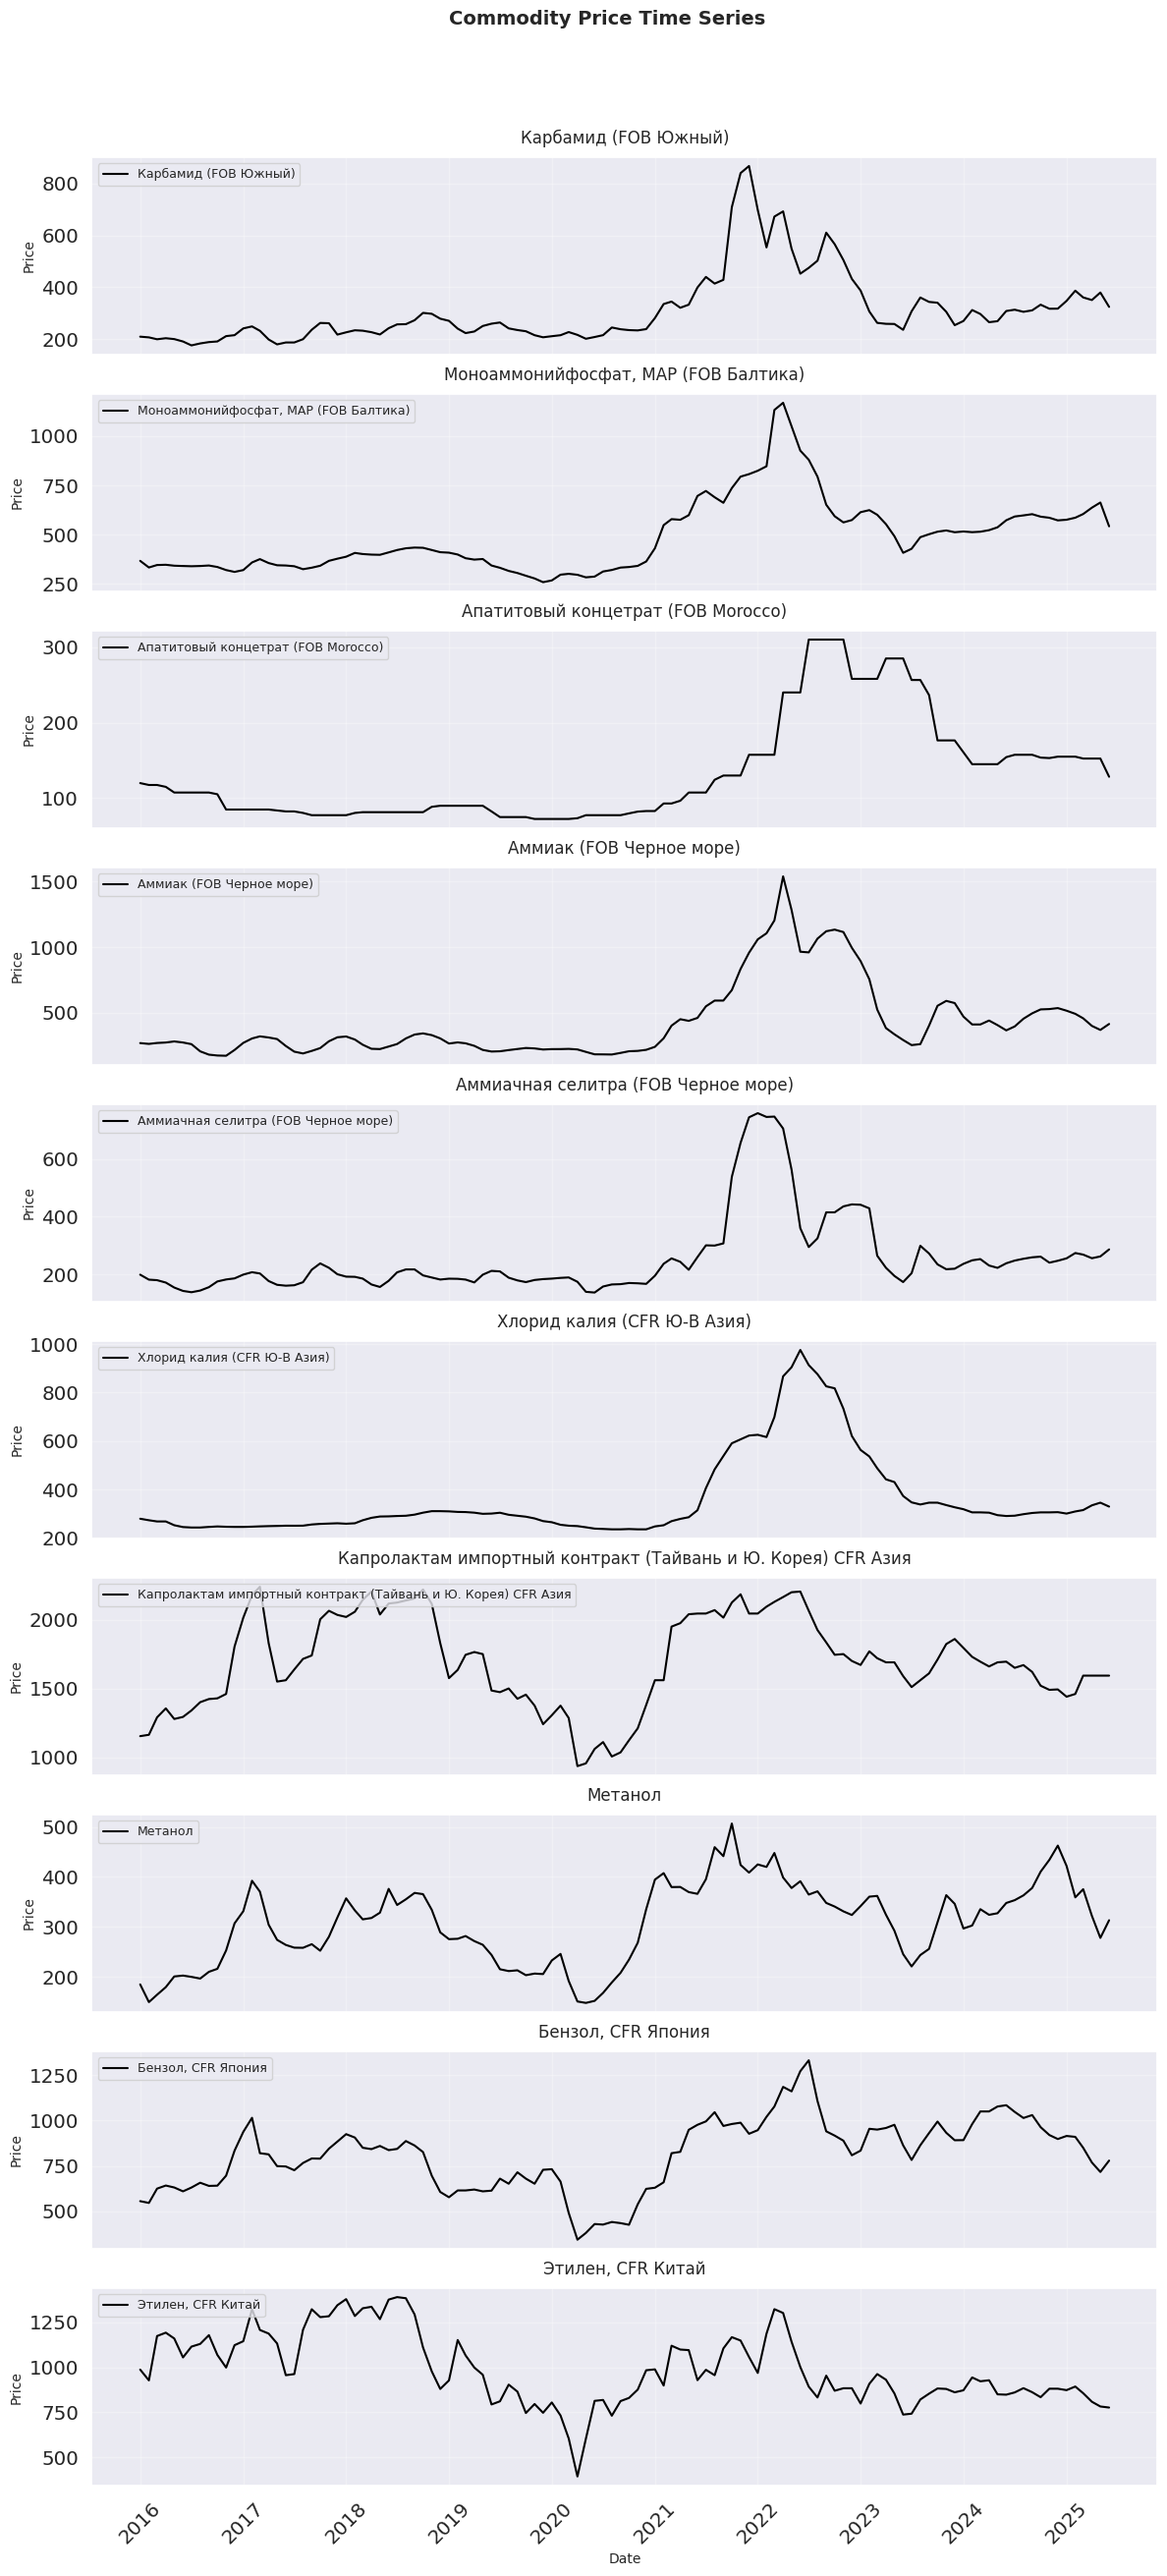

In [47]:
visualize_ts(df, df.columns, figsize=(14, 30))

## DFM

In [16]:
from utils.models import DynamicFactorModel

In [15]:
horizon_list = [12]

In [20]:
matrix_params = {
    "model_class": DynamicFactorModel,
    "df": df,
    "horizon": 12,
    "stride": 48,
    "start_window": 60,
    "model_params": {
        "k_factors": 3,
        "factor_order": 2,
        "error_order": 1,
        "enforce_stationarity": False,
        "maxiter": 500,
    },
}

In [ ]:
dfm_model_matrices = {}

for horizon in tqdm(horizon_list):
    matrix_params["horizon"] = horizon
    dfm_model_matrices[horizon] = build_short_error_matrix(**matrix_params)

  0%|          | 0/1 [00:00<?, ?it/s]/home/danilach/mipt-stats/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/danilach/mipt-stats/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
100%|██████████| 1/1 [00:26<00:00, 26.58s/it]


### Errors

  0%|          | 0/1 [00:00<?, ?it/s]

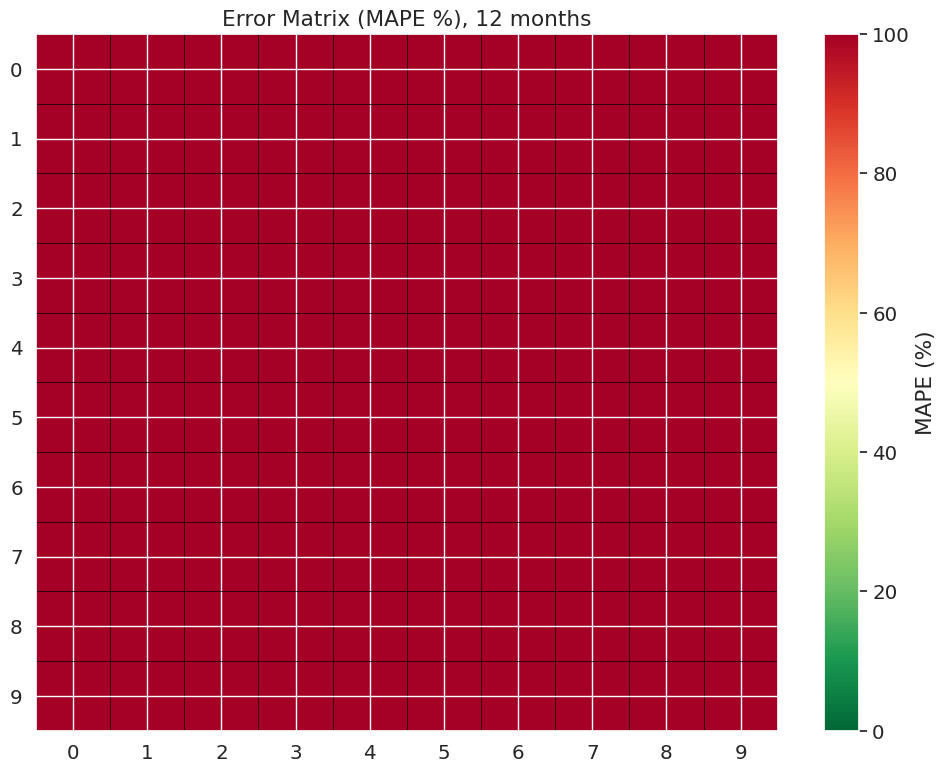

100%|██████████| 1/1 [00:00<00:00,  2.81it/s]


In [11]:
for horizon in tqdm(horizon_list):
    plot_error_matrix(dfm_model_matrices[horizon], title=f"Error Matrix (MAPE %), {horizon} months")

In [23]:
for horizon in horizon_list:
    print(f"{horizon} months:    ", end="")
    calc_average_error(dfm_model_matrices[horizon])

12 months:    58895.27%


/home/danilach/mipt-stats/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


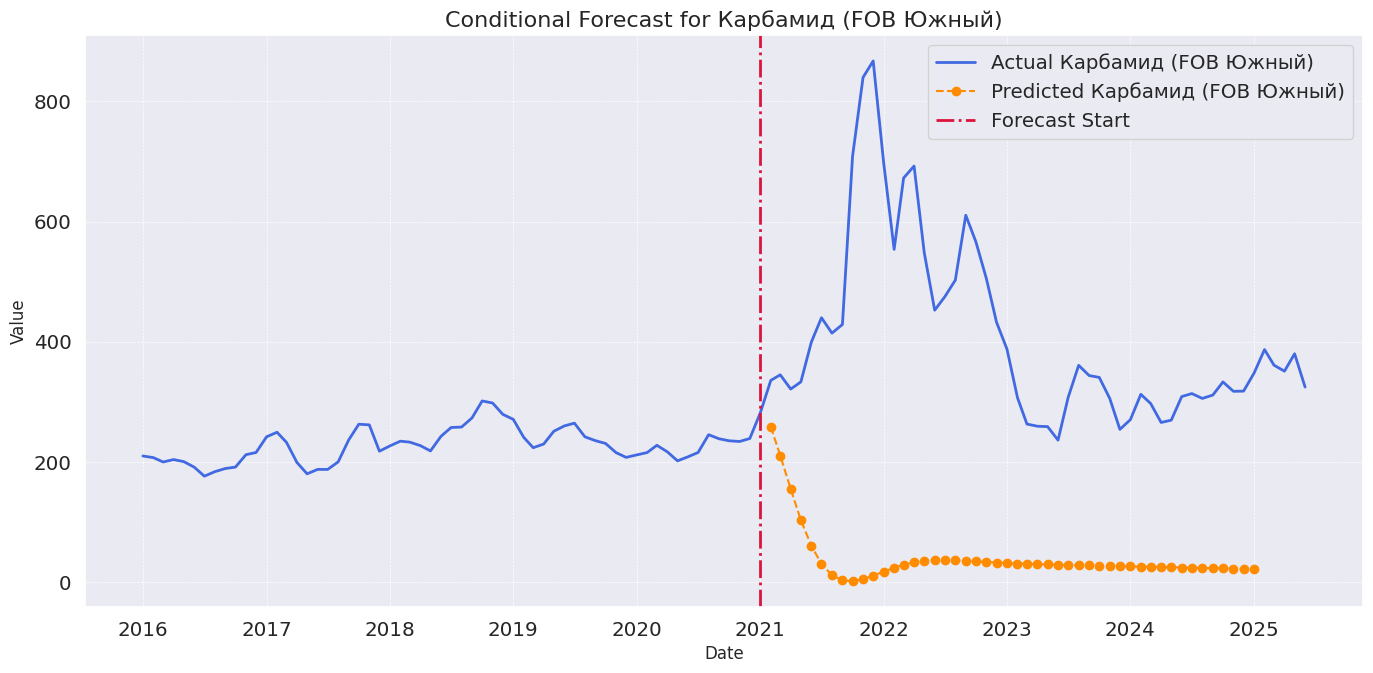

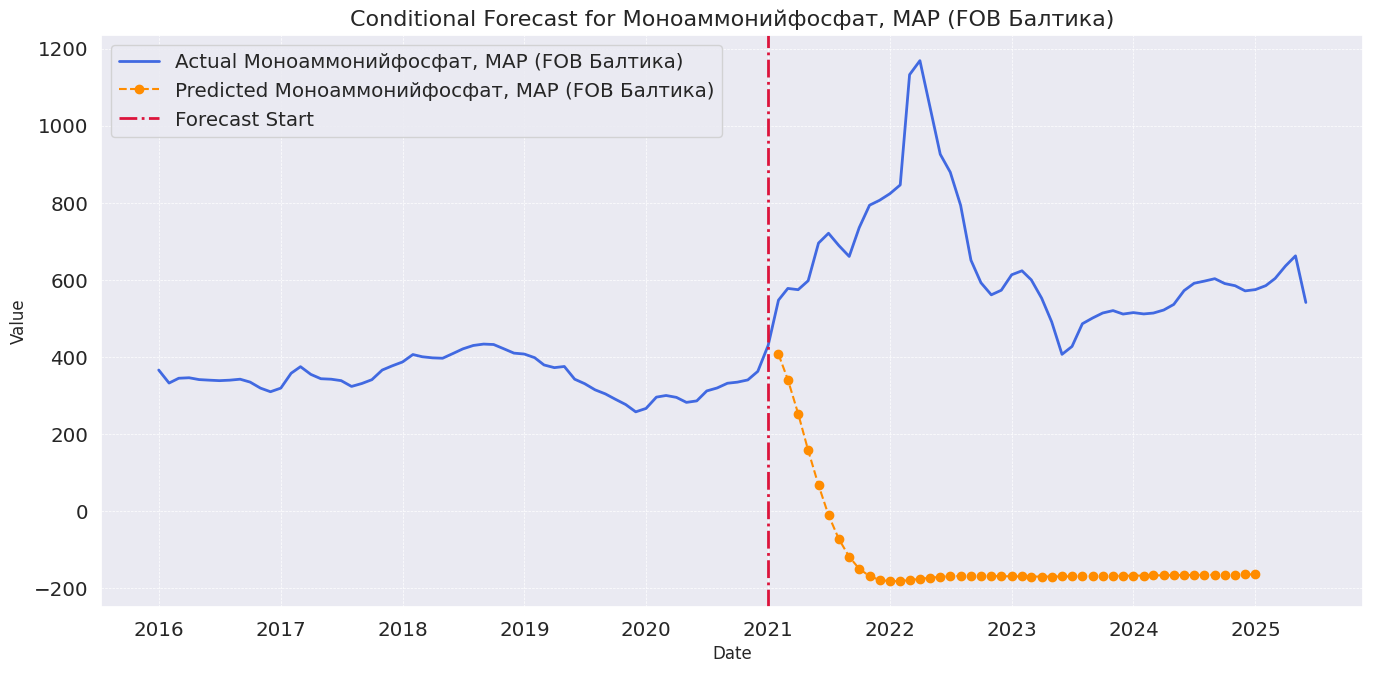

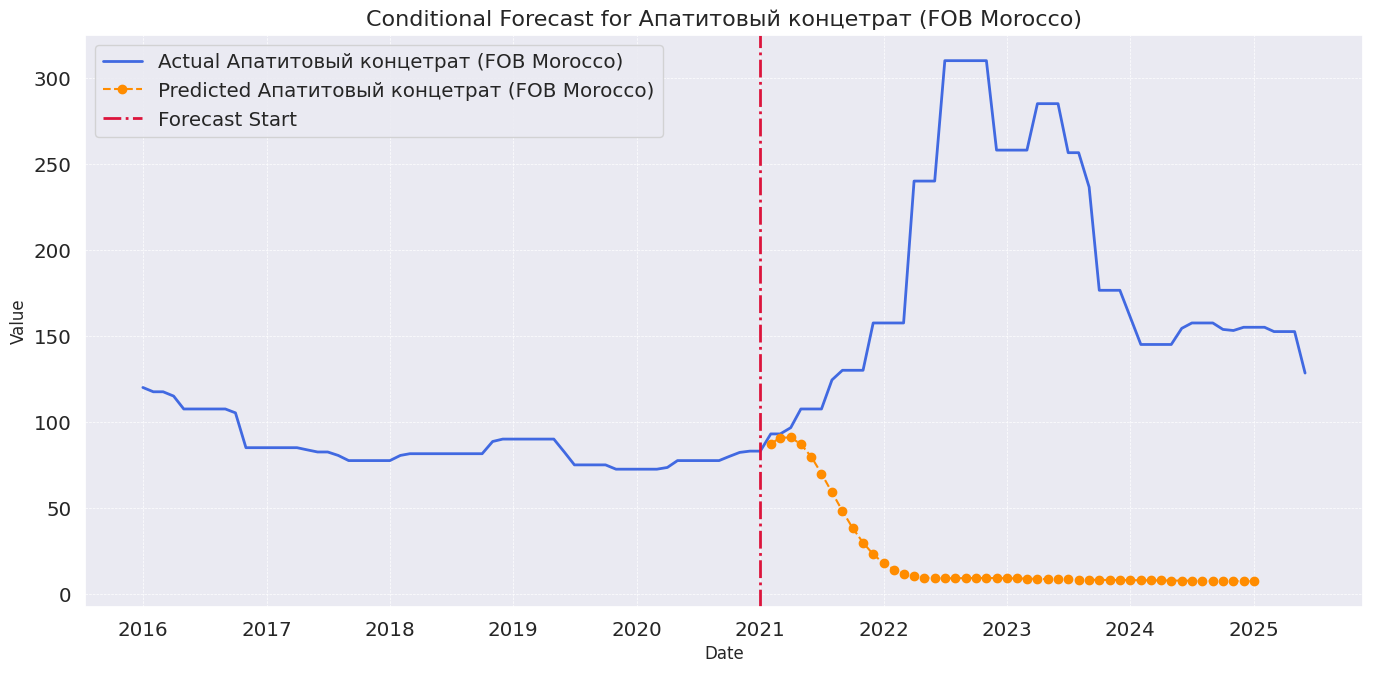

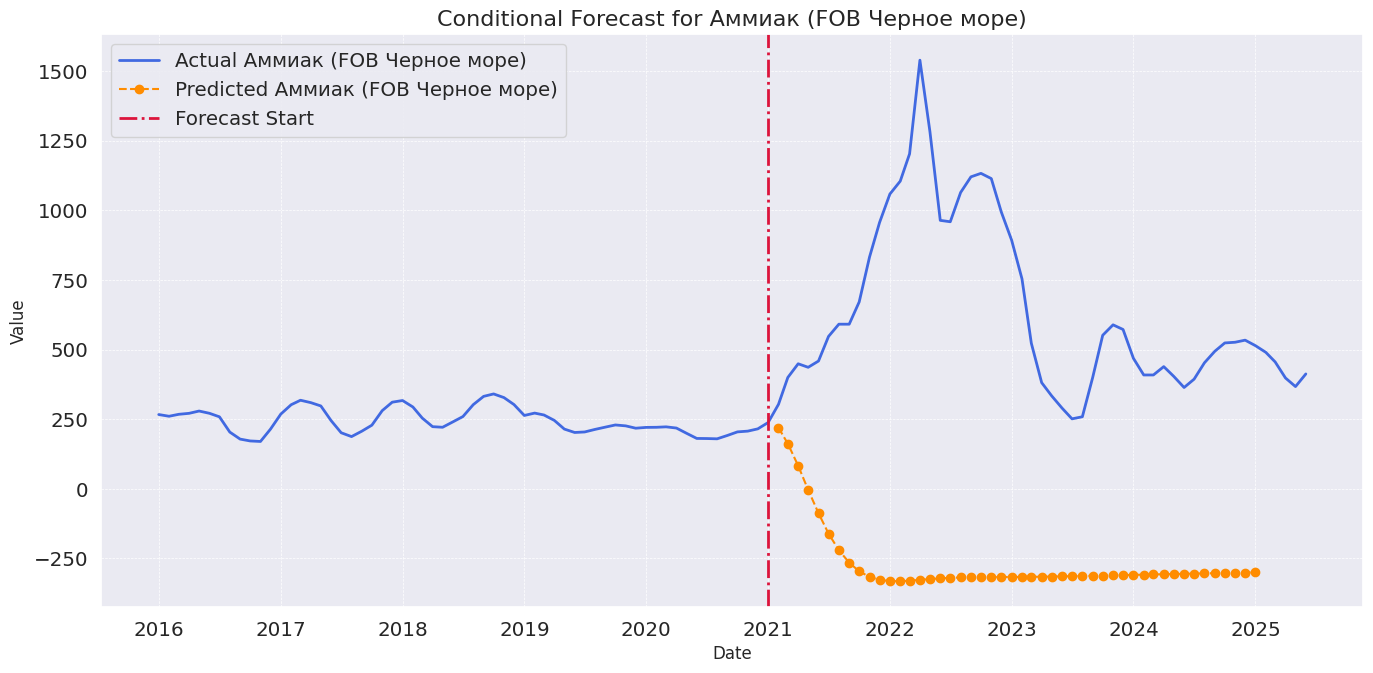

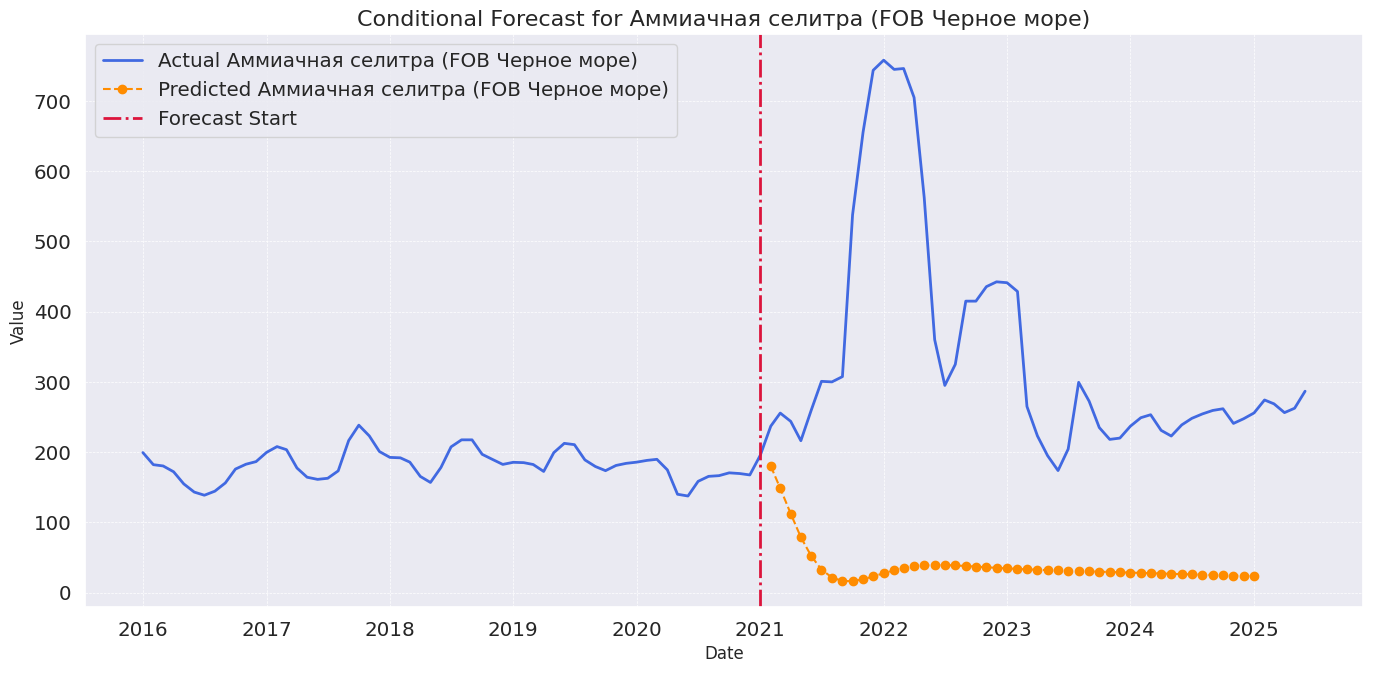

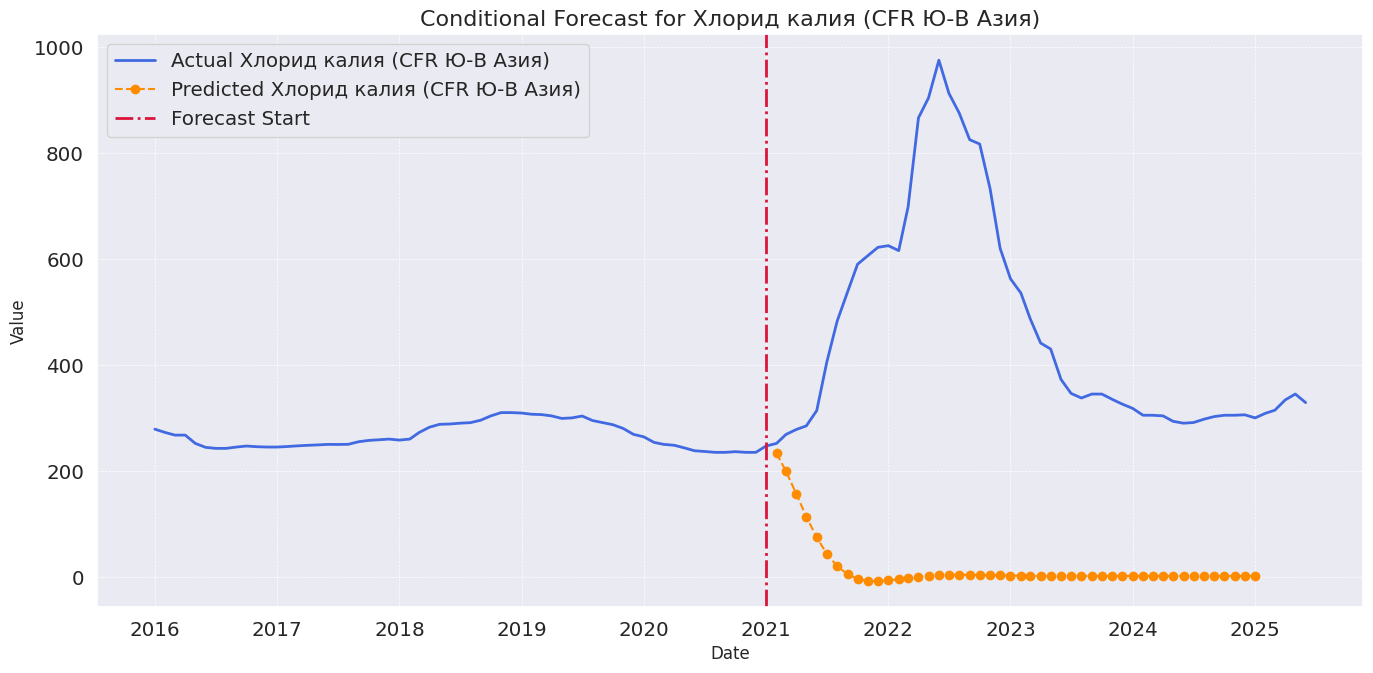

In [28]:
plot_model_pred(
    model_class=DynamicFactorModel,
    df=df[df.columns[:6]],
    model_params={"k_factors": 2, "factor_order": 2, "error_order": 1, "maxiter": 200},
    conditioning_col=df.columns[1],
    horizon=48,
    cutoff_date="2021-01-01",
)

In [31]:
df = pd.read_csv("/home/danilach/mipt-stats/SberTs/Data/apk_nona.csv", index_col=0)
df.index = pd.to_datetime(df.index)
cols = df.columns
df.head()       

,USDRUB,Кукуруза,Молоко сырое,Мясо птицы бройлеров в живом весе,Мясо крупного рогатого скота в живом весе,Подсолнечник,Пшеница 1-го класса,Пшеница 3-го класса,Пшеница 5-го класса,Сахар (средняя цена по России),...,"Минтай б/г, Владивосток руб./кг","Минтай б/г, Китай C&F $/т","Сельдь н/р, Владивосток руб./кг","Огурцы тепличные, руб./кг","Томаты тепличные, руб./кг",Колбасы вареные,"Рапс, руб./т","Рапсовое масло EU, $/т","Мука пшеничная, руб./т","Пшеница 12,5% FOB Ново, $/т"
2014-01-01,33.7787,5.10830,19.22489,53.78150,71.50234,9.35469,6.28054,6.64389,6.30182,20.62782,...,50.606061,1370.0,27.272727,109.69276,88.39199,180.11884,10.92124,959.902109,11.66556,281.67
2014-02-01,35.3147,5.52927,20.10432,53.73414,70.26937,8.94873,6.70380,6.83535,6.17293,21.04715,...,46.969697,1400.0,26.590909,133.35480,95.80819,185.95226,11.77707,1025.767008,11.59769,278.50
2014-03-01,36.1269,5.55814,20.39963,54.36590,70.87358,10.37450,7.57283,7.18896,6.00571,22.35493,...,53.939394,1390.0,27.272727,103.82040,85.61886,189.09688,13.14795,1008.712498,11.78734,290.75
2014-04-01,35.6723,6.12138,20.49657,55.41361,71.26701,10.97702,8.14327,7.54990,6.58360,24.33316,...,48.000000,1425.0,28.181818,86.43050,109.40309,191.13037,12.71399,1016.669062,12.26536,291.00
2014-05-01,34.8429,6.69644,20.06417,58.83824,73.39434,11.59955,10.16825,8.12811,7.10044,25.66925,...,47.727273,1440.0,23.863636,61.65754,82.03765,196.68823,11.03515,957.679643,12.84780,269.75


/home/danilach/mipt-stats/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/danilach/mipt-stats/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


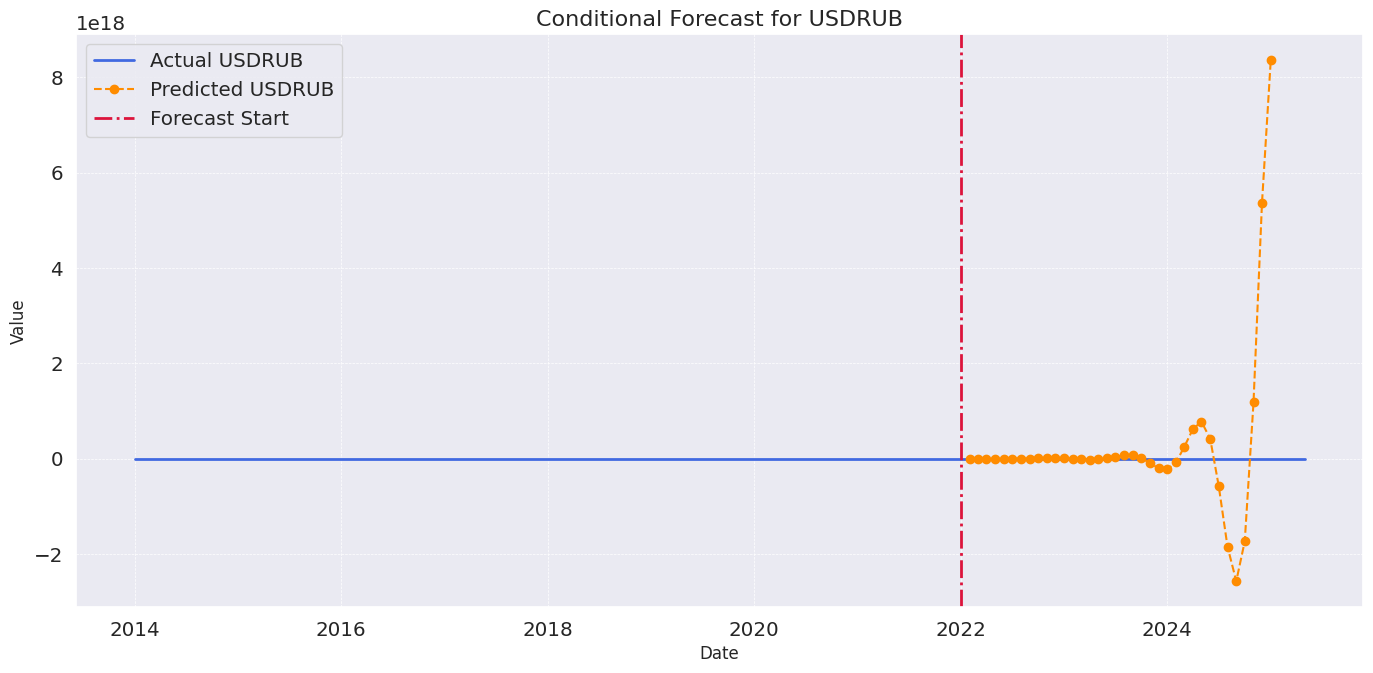

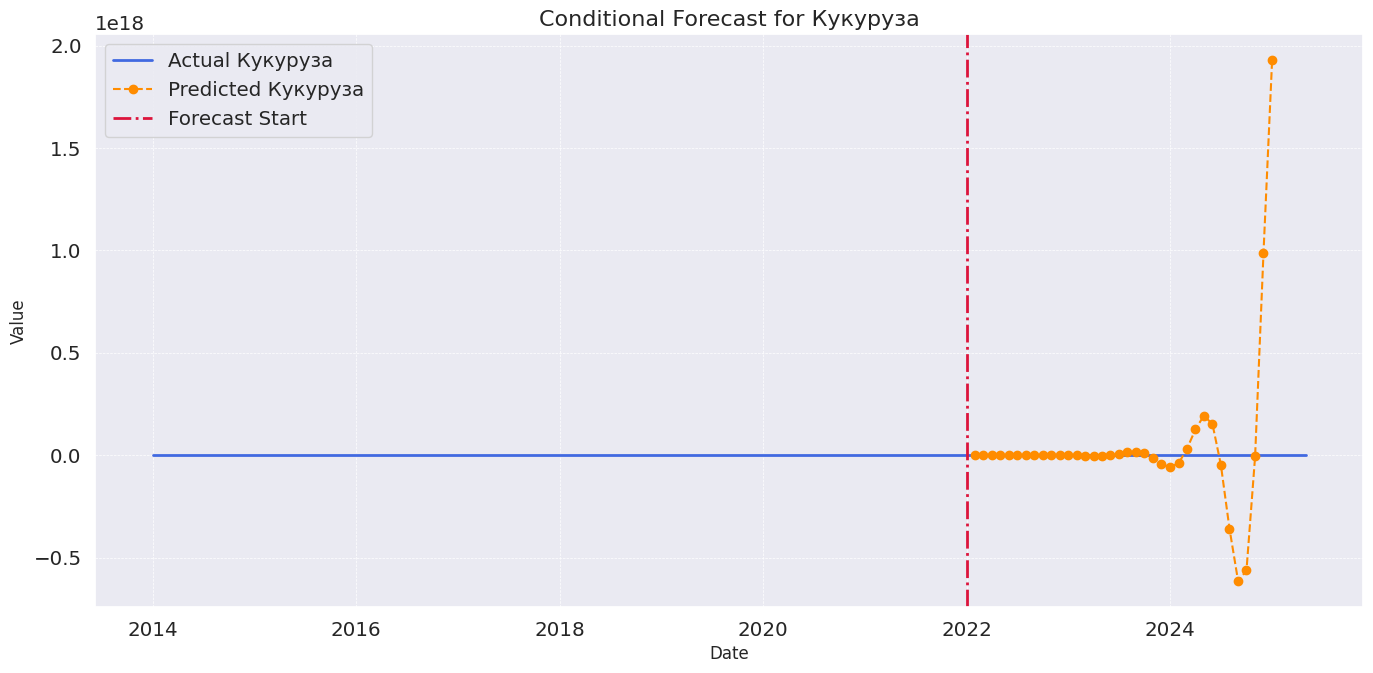

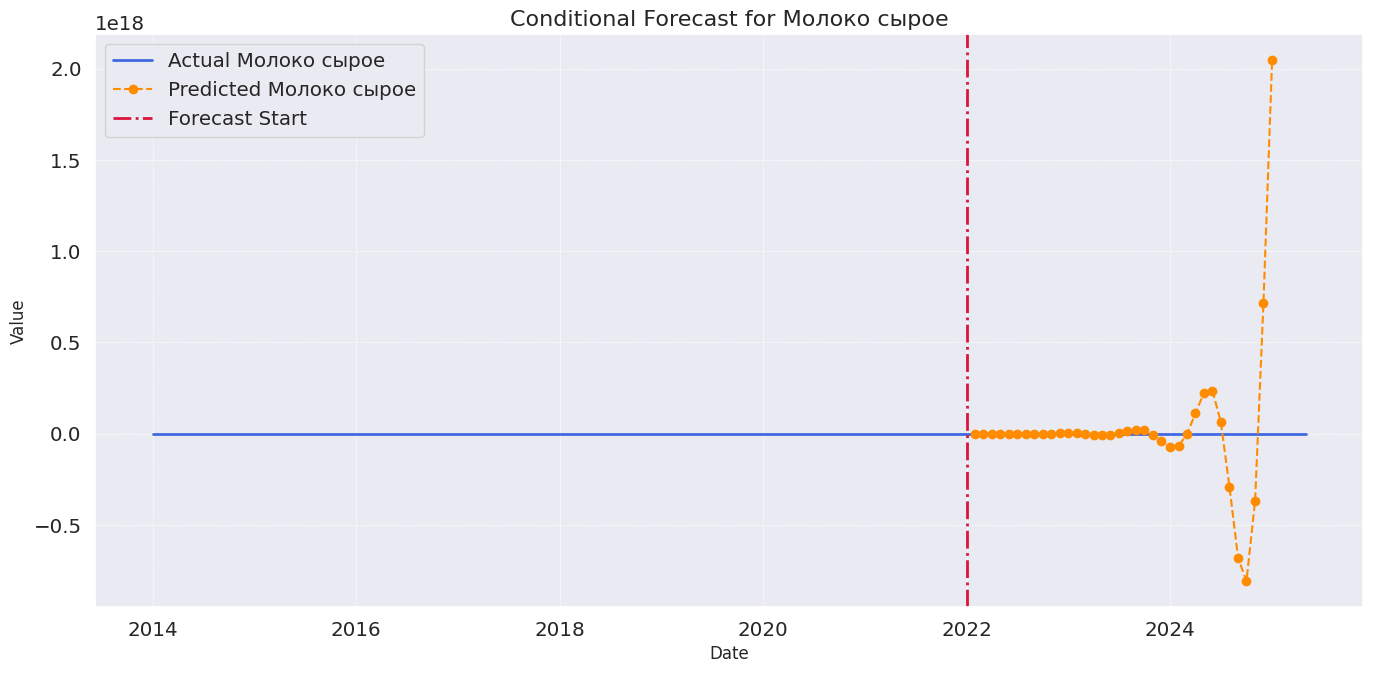

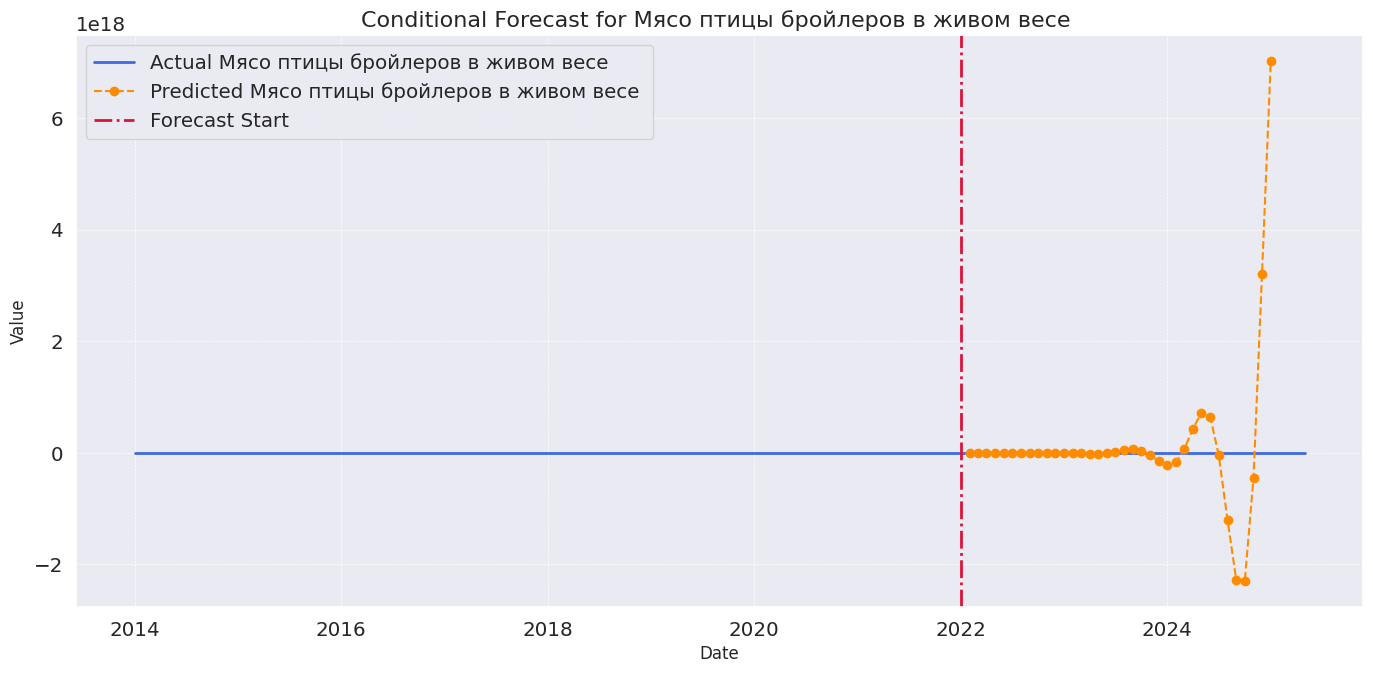

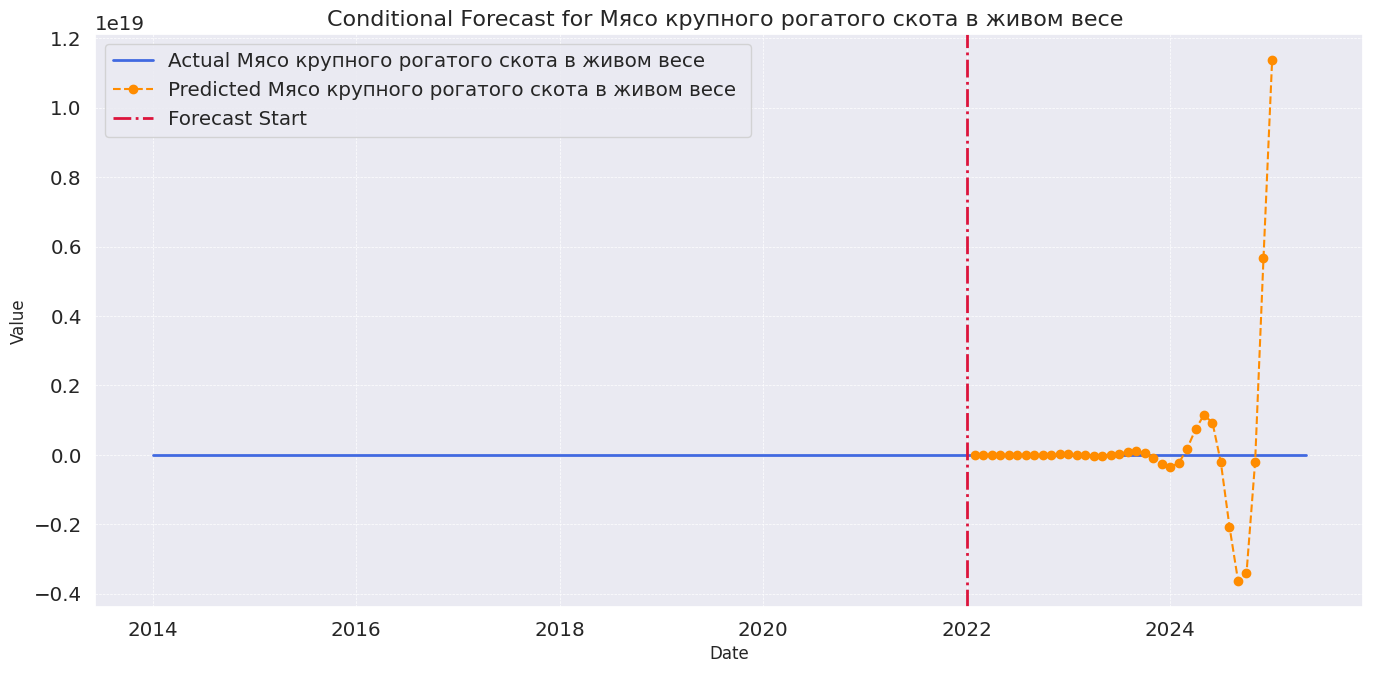

In [44]:
plot_model_pred(
    model_class=DynamicFactorModel,
    df=df[df.columns[:5]],
    model_params={"k_factors": 3, "factor_order": 4, "error_order": 0, "maxiter": 30, "enforce_stationarity": False},
    conditioning_col=df.columns[3],
    horizon=36,
    cutoff_date="2022-01-01",
)

/home/danilach/mipt-stats/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/danilach/mipt-stats/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


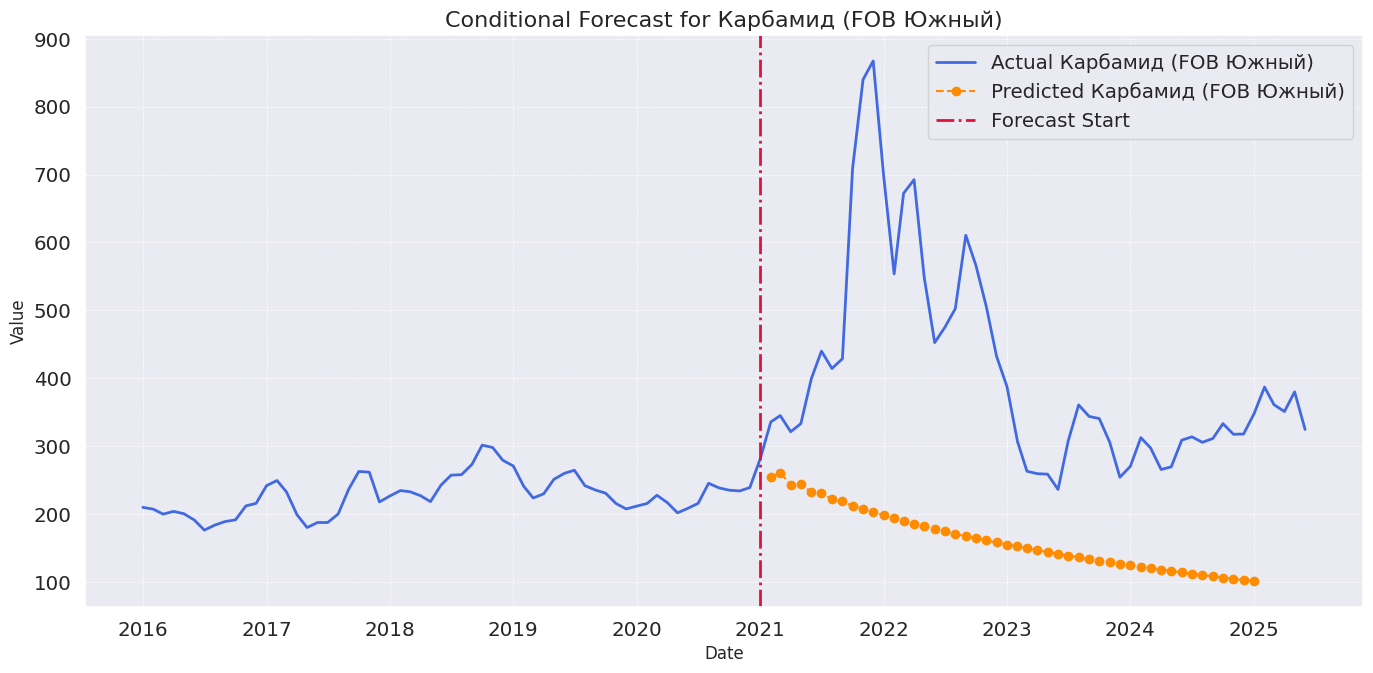

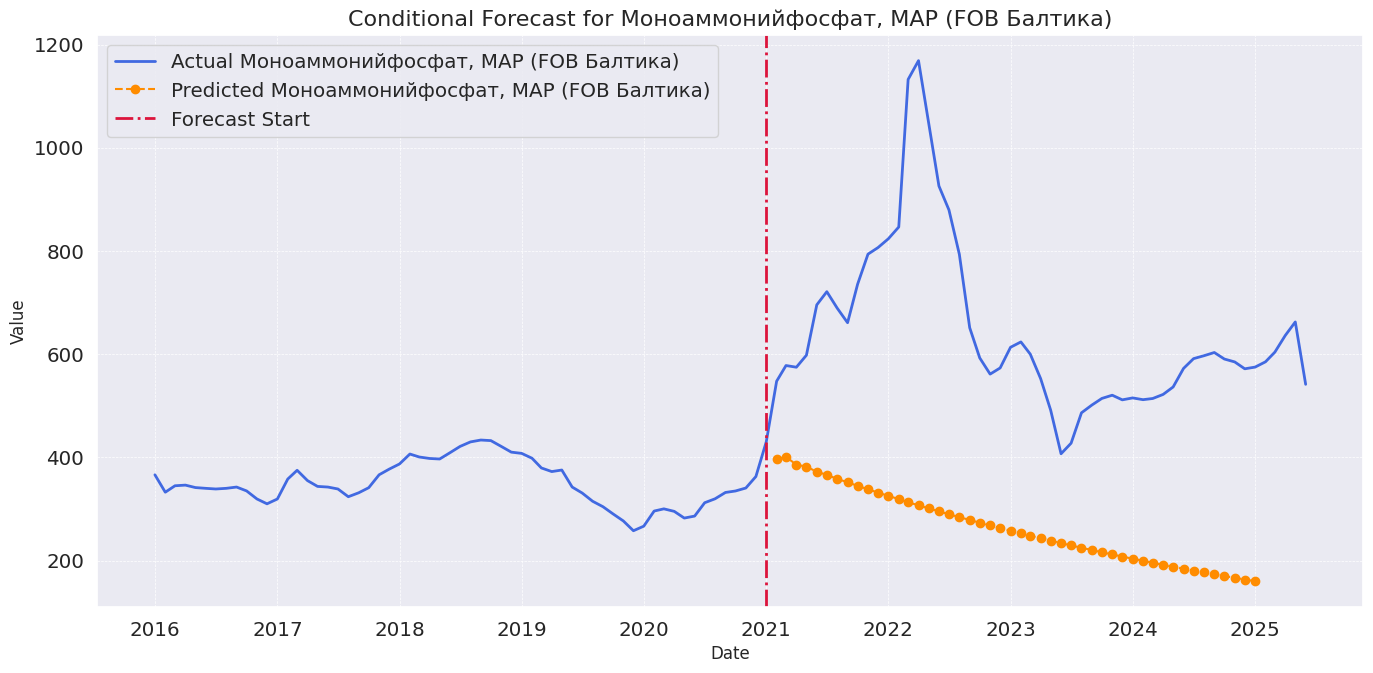

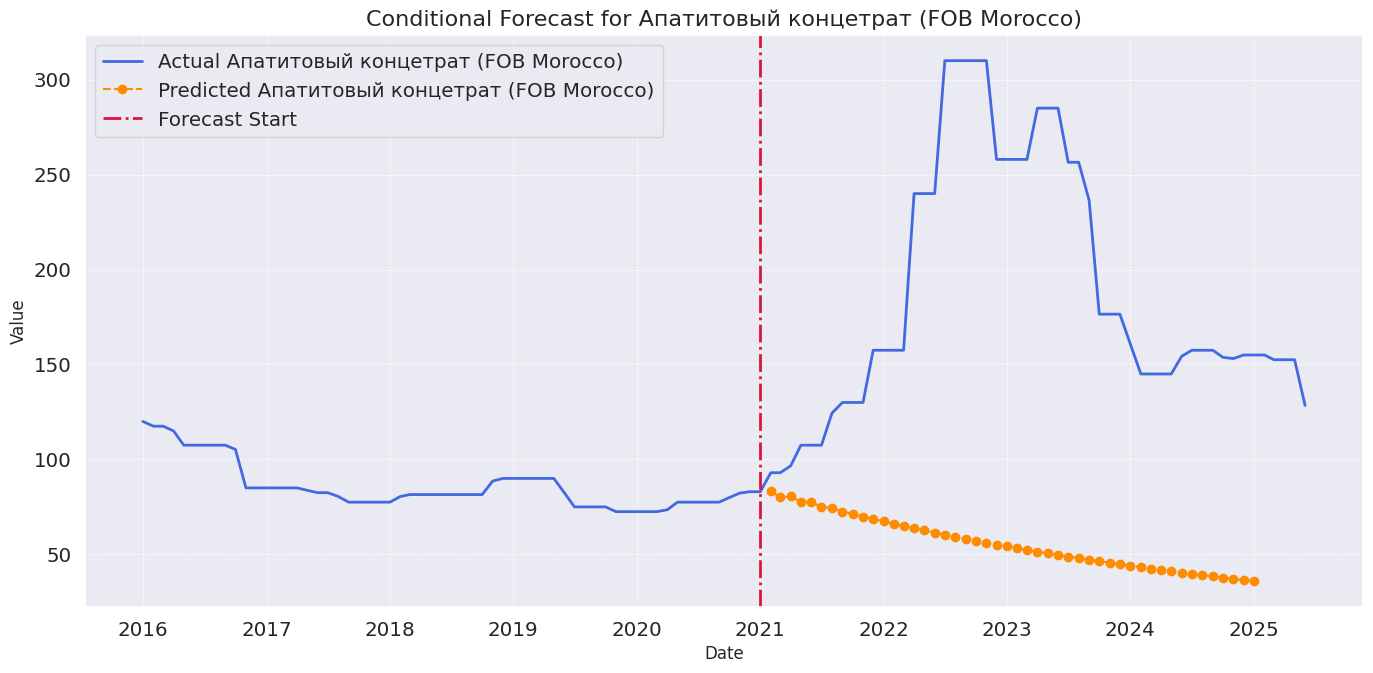

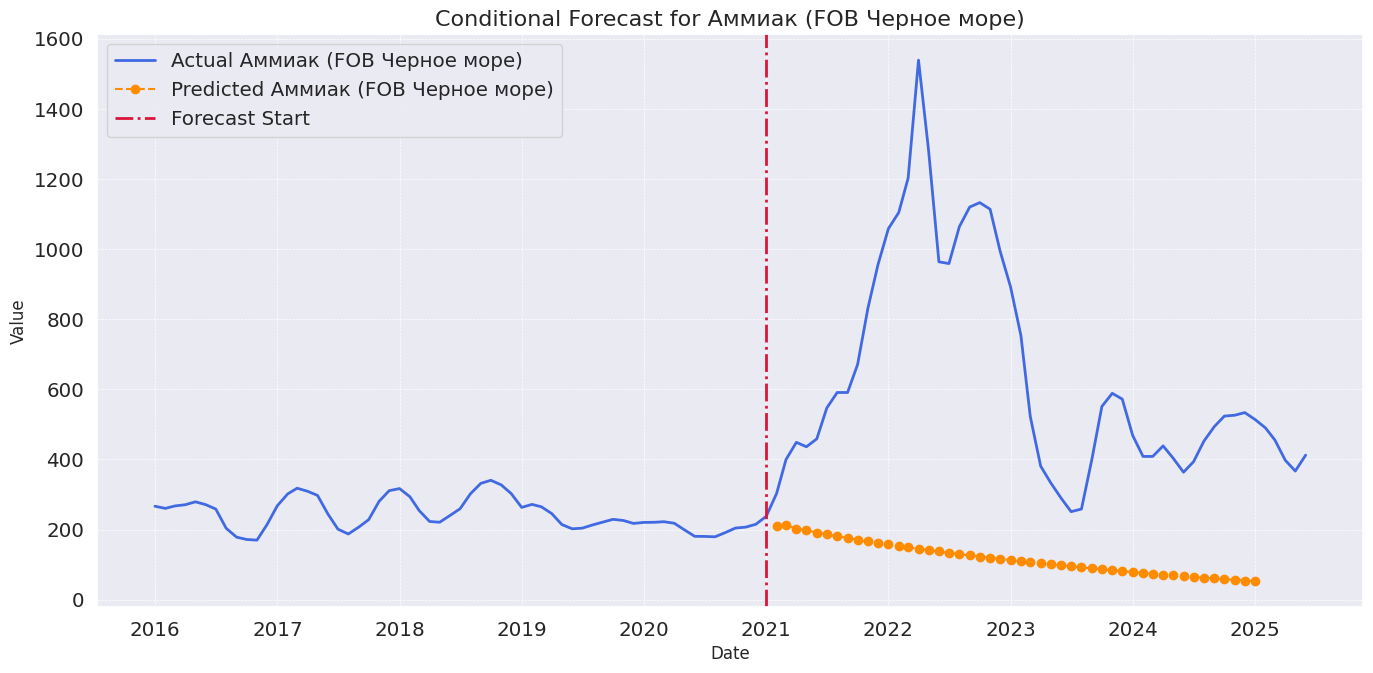

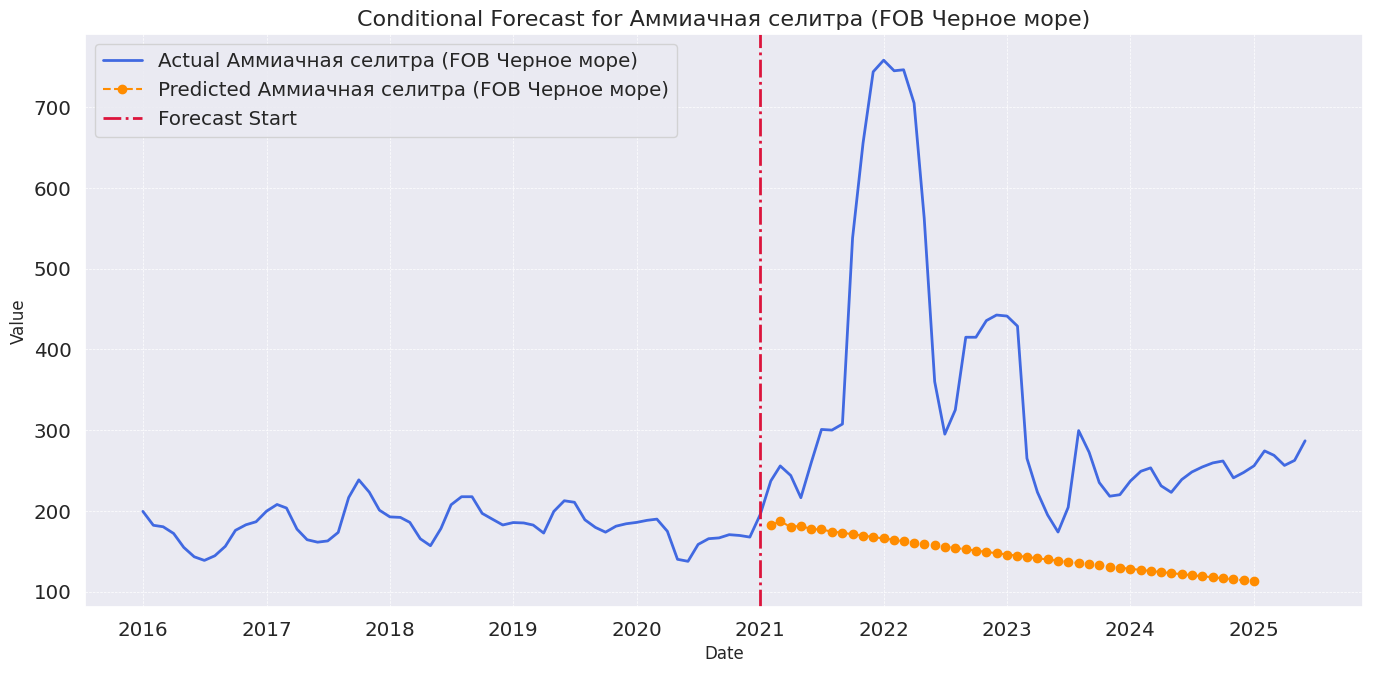

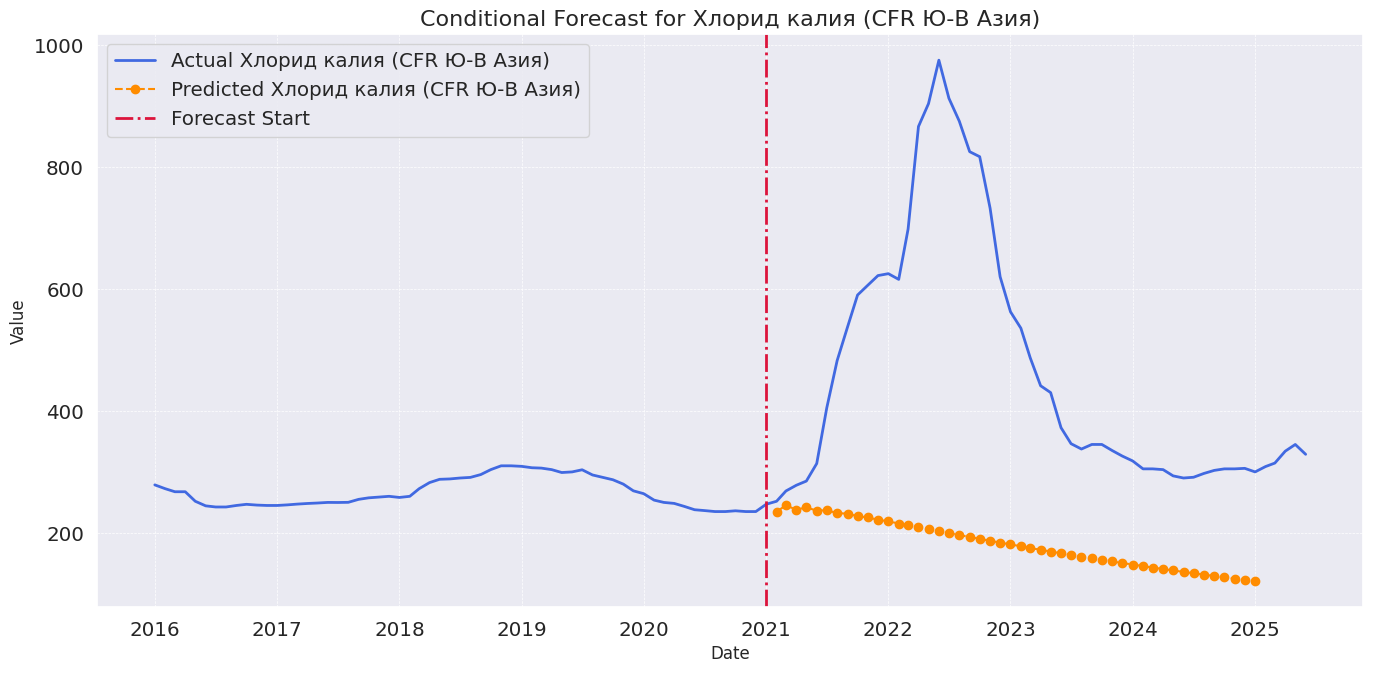

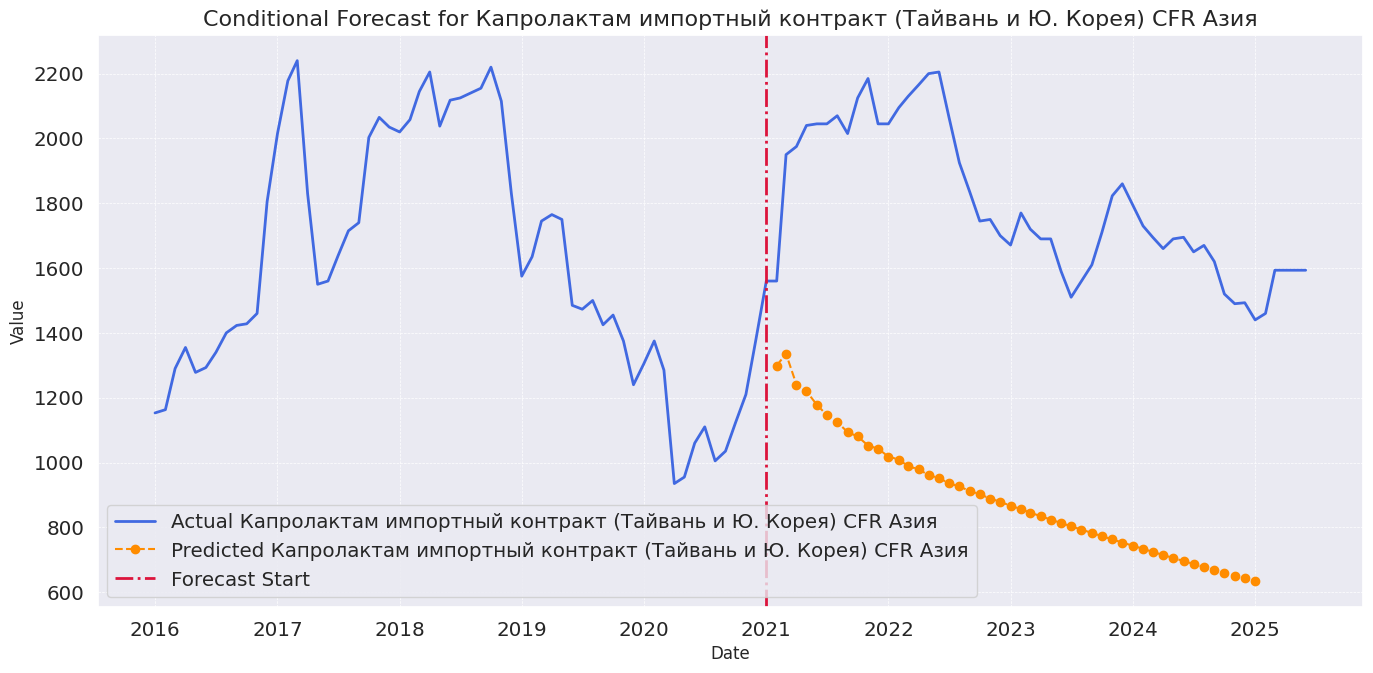

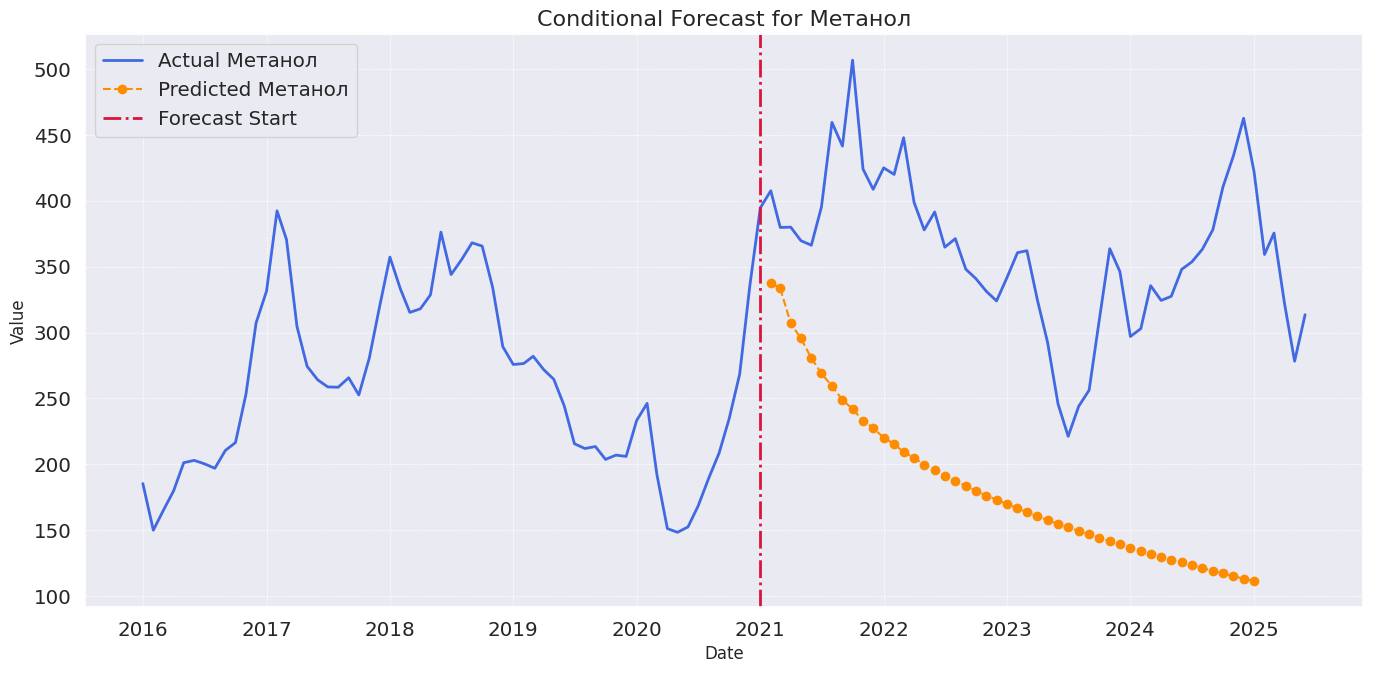

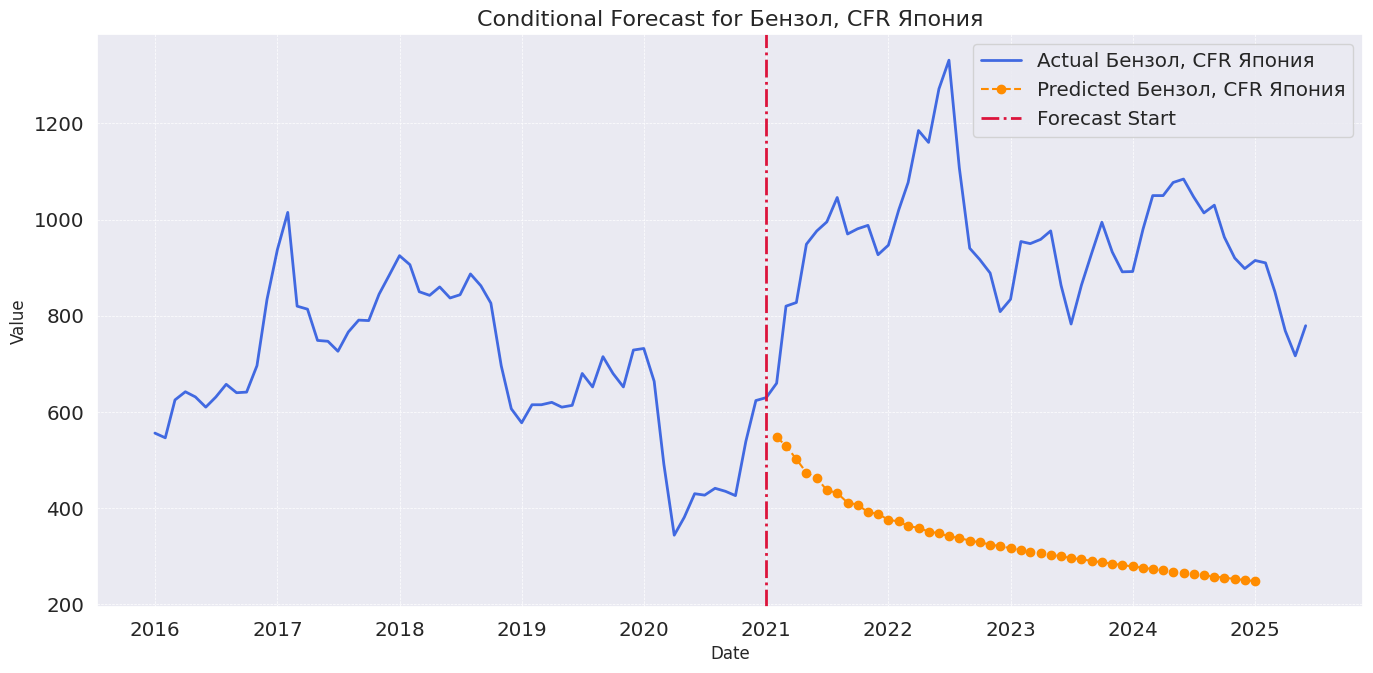

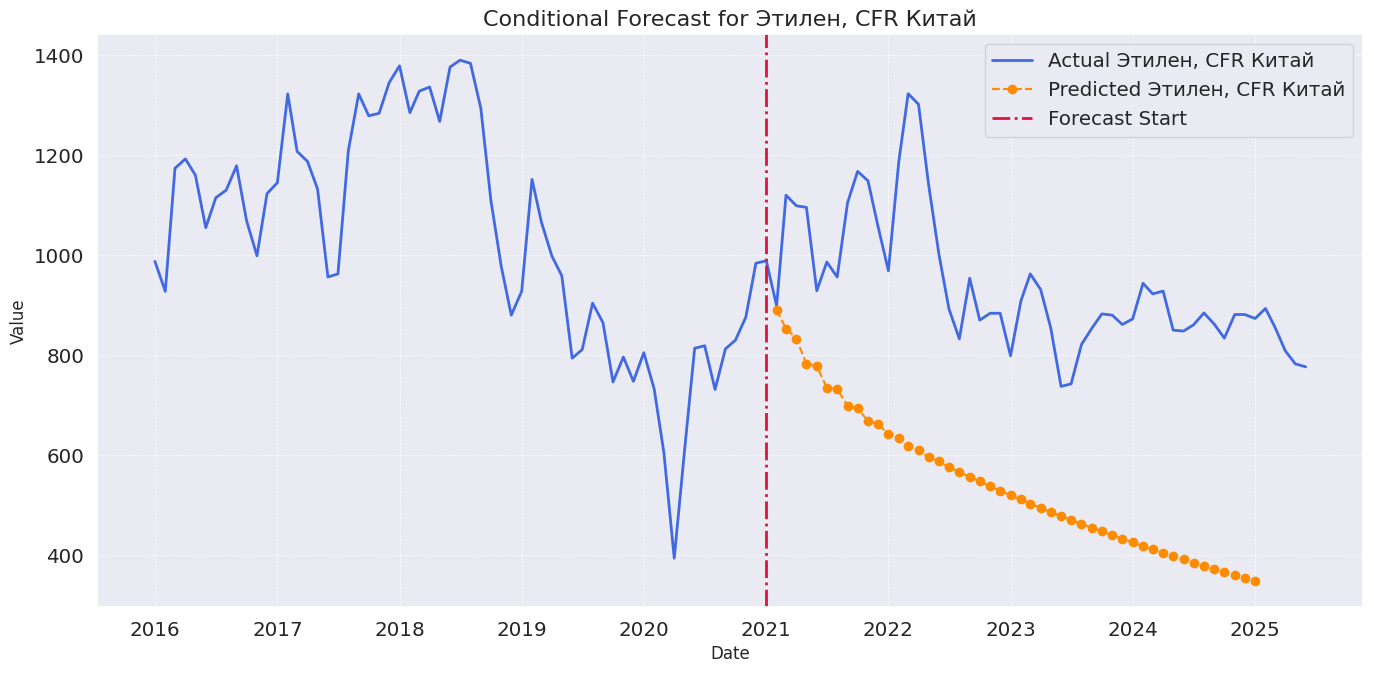

In [30]:
plot_model_pred(
    model_class=DynamicFactorModel,
    df=df,
    model_params={"k_factors": 3, "factor_order": 2, "error_order": 1, "maxiter": 100},
    conditioning_col=df.columns[3],
    horizon=48,
    cutoff_date="2021-01-01",
)